In [1]:
import pandas as pd

stocks = pd.read_csv('S&P 500/all_stocks_5yr.csv', parse_dates=['date'], index_col='date')
stocks.rename(columns={'Name':'ticks'}, inplace=True)
stocks.sort_values(by=['date', 'ticks'], inplace=True)

In [3]:
print('Number of Stocks: {}'.format(stocks.ticks.nunique()))

Number of Stocks: 505


In [4]:
stocks.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [5]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 619040 entries, 2013-02-08 to 2018-02-07
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   open    619029 non-null  float64
 1   high    619032 non-null  float64
 2   low     619032 non-null  float64
 3   close   619040 non-null  float64
 4   volume  619040 non-null  int64  
 5   ticks   619040 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 33.1+ MB


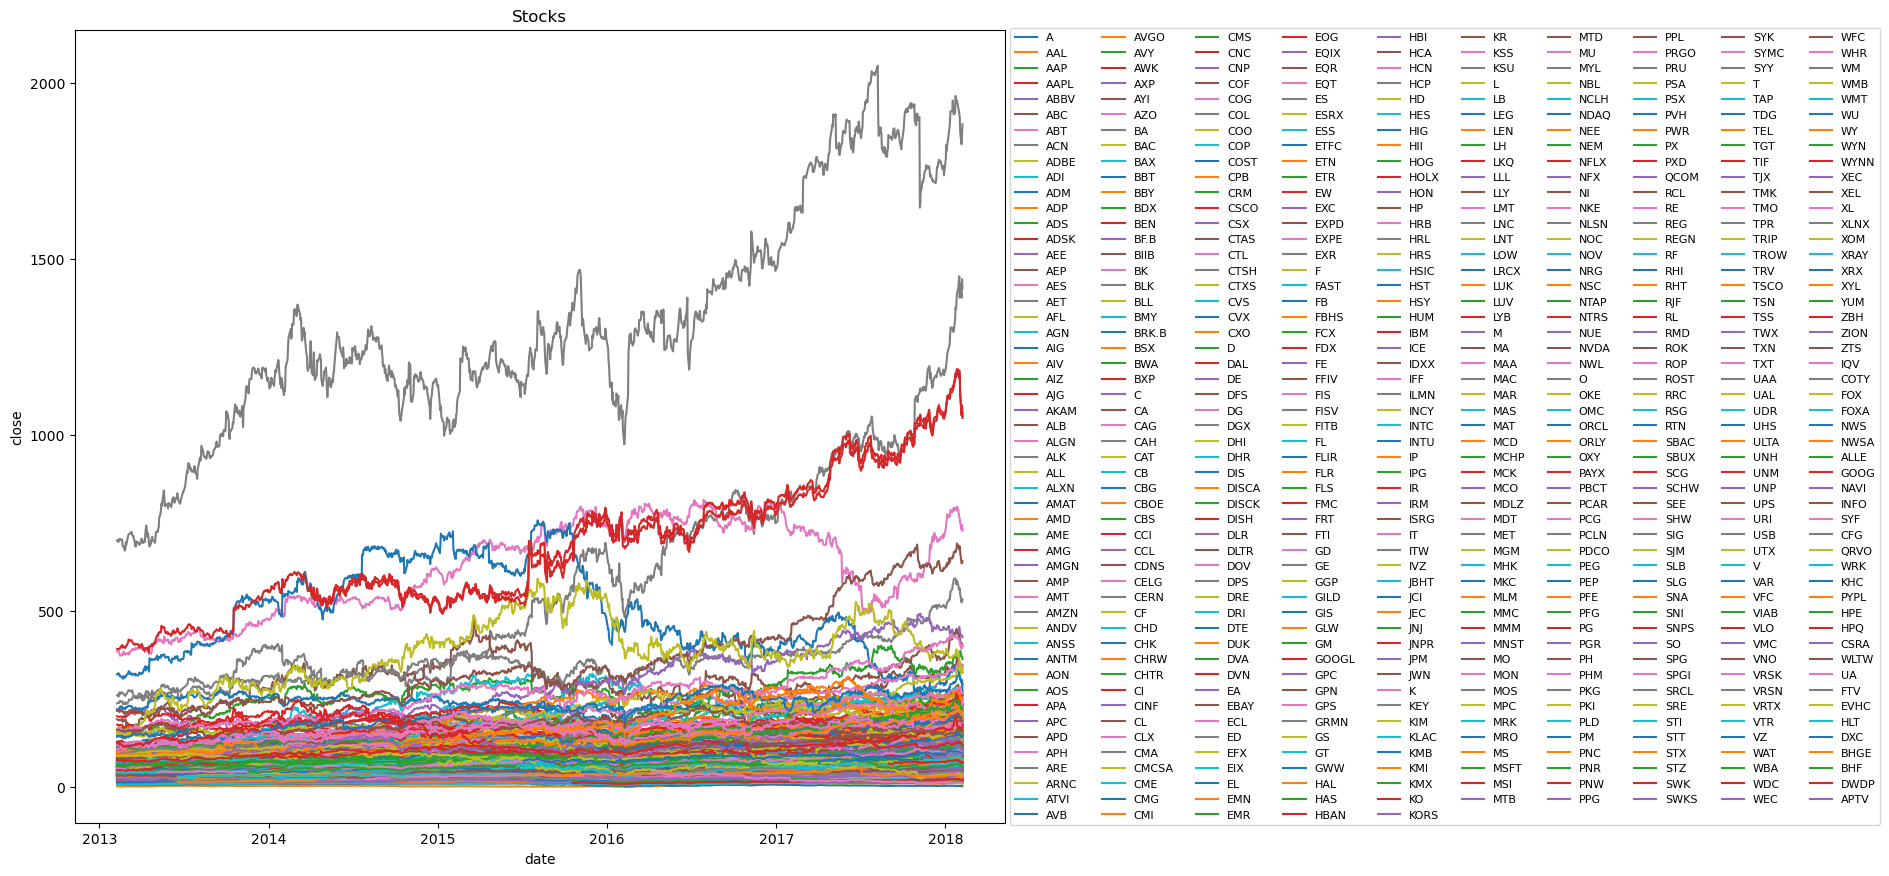

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10.3))
sns.lineplot(data=stocks, x='date', y='close', hue='ticks', palette='tab10')
plt.legend(bbox_to_anchor=(1.00, 1.009), loc='upper left', ncol=10, fontsize=8)
plt.title('Stocks')
plt.show()

In [7]:
# Ensure sufficient trading volume
min_avg_volume = stocks.groupby('ticks')['volume'].mean()
liquid_stocks = min_avg_volume[min_avg_volume > min_avg_volume.quantile(0.3)].index.tolist()

# Avoid penny stocks or overly expensive stocks
price_check = stocks.groupby('ticks')['close'].last()
reasonable_price = price_check[(price_check > 10) & (price_check < 500)].index.tolist()

# Check for missing data gaps
data_completeness = stocks.groupby('ticks').size()
complete_data = data_completeness[data_completeness >= data_completeness.quantile(0.8)].index.tolist()

valid_tickers = list(set(liquid_stocks) & set(reasonable_price) & set(complete_data))
filtered_stocks = stocks[stocks['ticks'].isin(valid_tickers)]

print(f"Original tickers: {stocks['ticks'].nunique()}")
print(f"Volume filter: {len(liquid_stocks)}")
print(f"Price filter: {len(reasonable_price)}")  
print(f"Completeness filter: {len(complete_data)}")
print(f"Final filtered tickers: {len(valid_tickers)}")

Original tickers: 505
Volume filter: 353
Price filter: 497
Completeness filter: 470
Final filtered tickers: 322


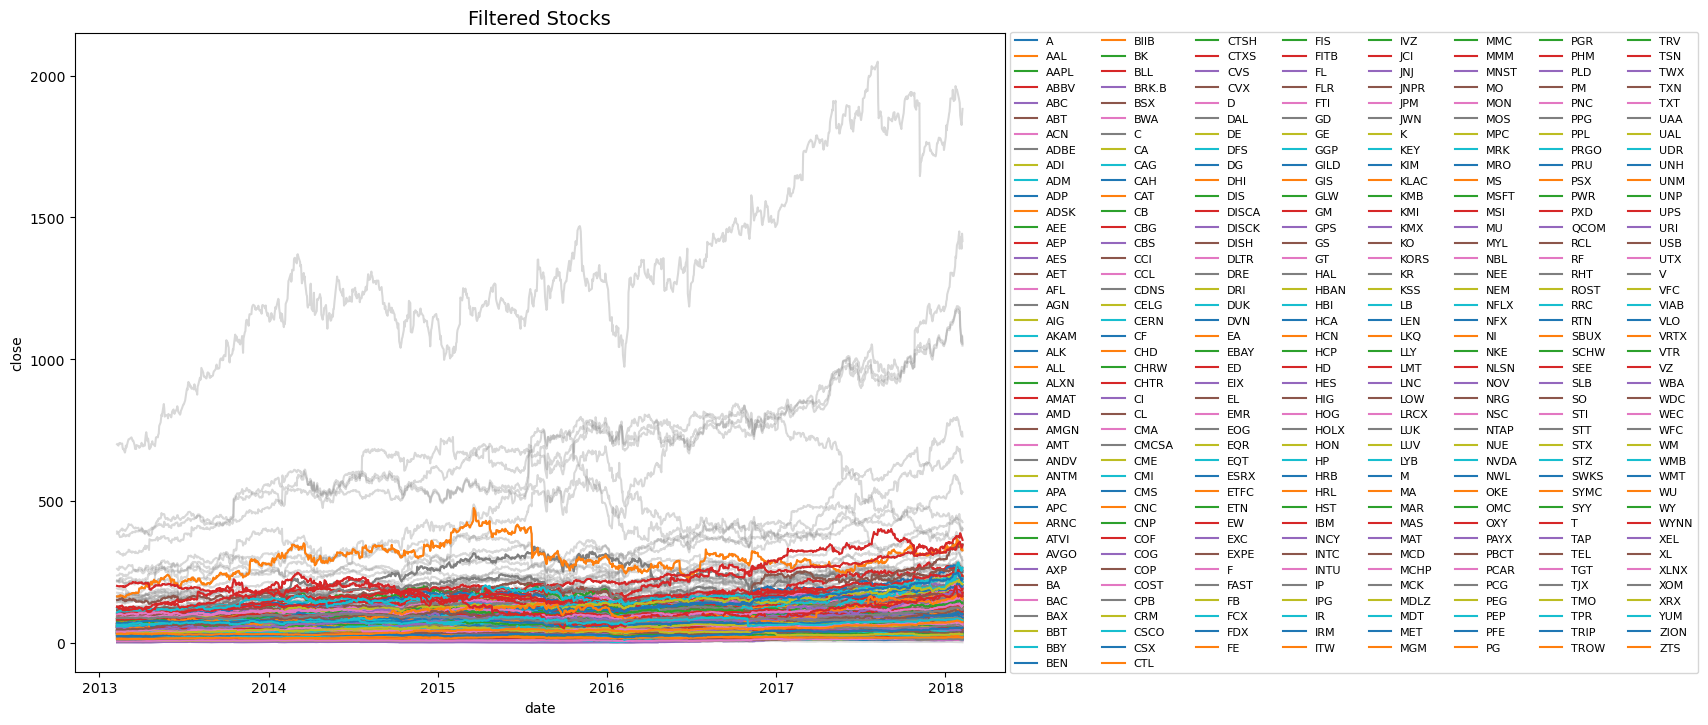

In [8]:
plt.figure(figsize=(12, 8.3))

sns.lineplot(data=stocks, x='date', y='close', units='ticks', 
             estimator=None, color='grey', alpha=0.3, legend=False)

sns.lineplot(data=filtered_stocks, x='date', y='close', hue='ticks', palette='tab10')
plt.legend(bbox_to_anchor=(1.00, 1.01), loc='upper left', ncol=8, fontsize=8)
plt.title('Filtered Stocks', fontsize=14)
plt.show()

In [9]:
recent_12m = filtered_stocks[filtered_stocks.index >= (filtered_stocks.index.max() - pd.DateOffset(months=12))]

# Calculate metrics on recent data
# pivot = recent_12m.pivot(index='date', columns='ticks', values='close')
# daily_returns = pivot.pct_change().dropna()

In [10]:
recent_12m

,open,high,low,close,volume,ticks
date,,,,,,
2017-02-07,49.42,49.780,49.26,49.64,2170720,A
2017-02-07,45.75,46.130,45.01,45.17,6119960,AAL
2017-02-07,130.54,132.090,130.45,131.53,38183841,AAPL
2017-02-07,60.65,60.870,60.40,60.56,4210335,ABBV
2017-02-07,89.85,91.640,89.71,90.33,2108481,ABC
...,...,...,...,...,...,...
2018-02-07,78.44,79.410,76.92,76.94,21994450,XOM
2018-02-07,30.73,31.405,30.73,31.18,2983504,XRX
2018-02-07,80.07,81.940,80.00,80.13,3561068,YUM


In [11]:
recent_12m.reset_index(inplace=True)

In [12]:
def CAGR(group):
    group = group.sort_values('date')
    start_price = group['close'].iloc[0]
    end_price = group['close'].iloc[-1]
    
    start_date = group['date'].iloc[0]
    end_date = group['date'].iloc[-1]
    years = (end_date - start_date).days / 365.25
    
    if years <= 0:
        return np.nan
        
    return ((end_price / start_price) ** (1/years)) - 1

# Ensure your data is clean
recent_12m = recent_12m.sort_values(['ticks', 'date'])
growth_rates = recent_12m.groupby('ticks').apply(CAGR)

/tmp/ipykernel_33901/3641876644.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  growth_rates = recent_12m.groupby('ticks').apply(CAGR)


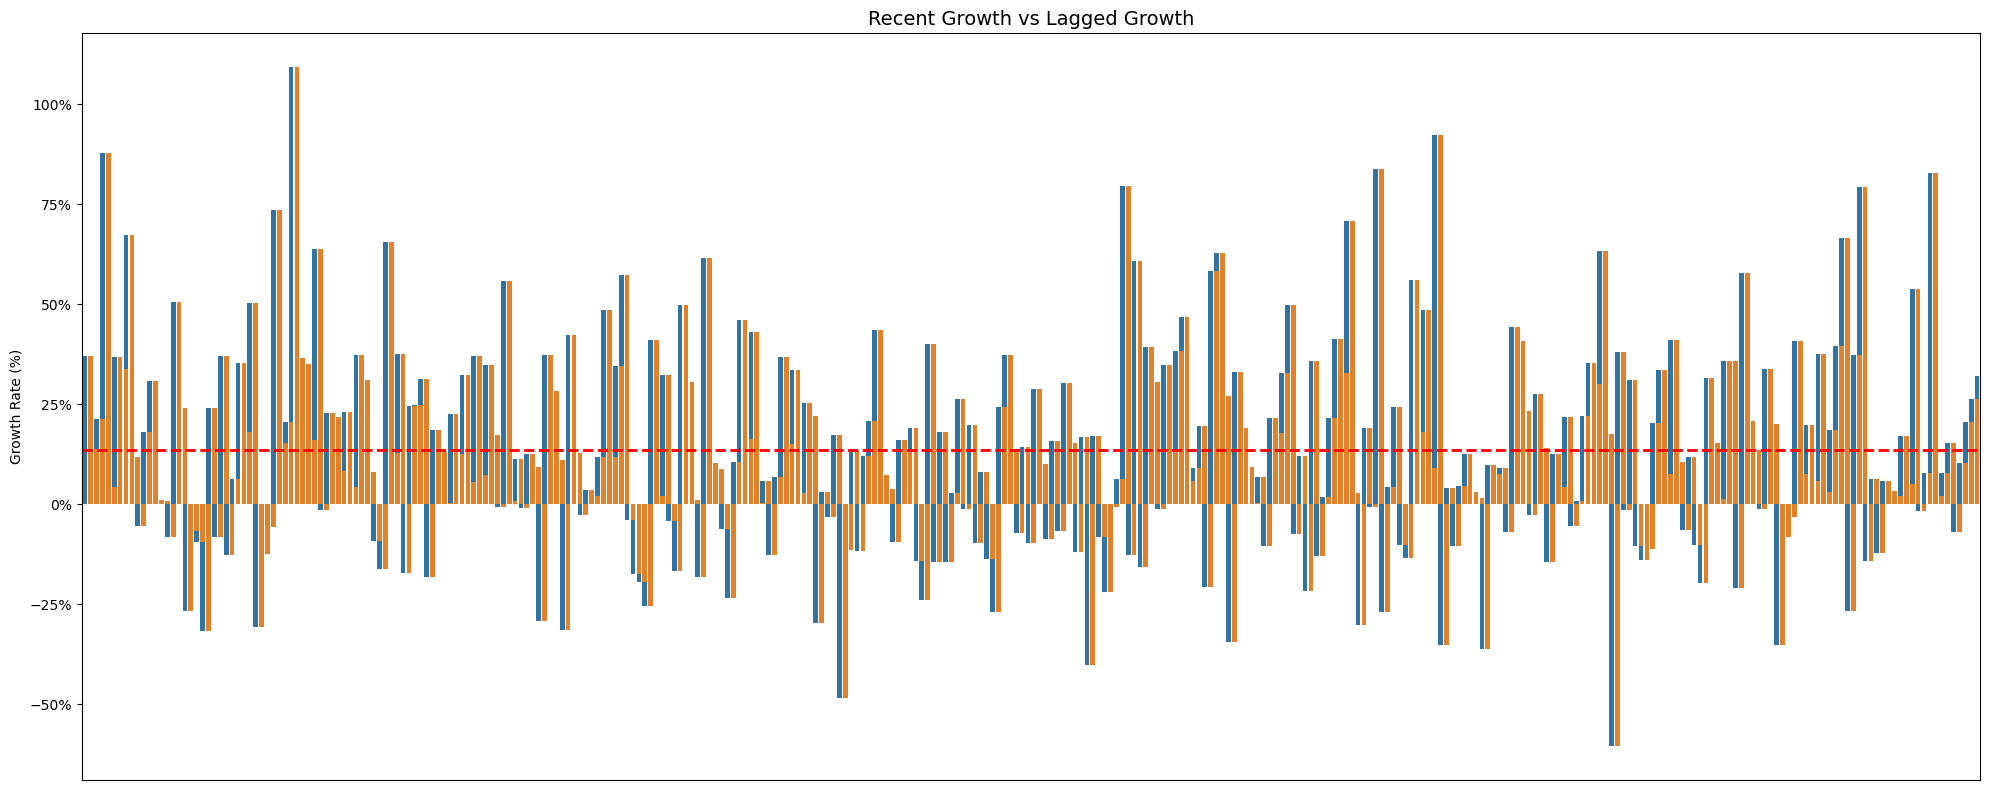

In [336]:
from matplotlib.ticker import PercentFormatter
from scipy import stats
import numpy as np

lagged_growth = growth_rates.shift(1)
avg_growth = growth_rates.mean()
avg_lagged = lagged_growth.mean()
avg_lagged_growth = np.minimum(avg_growth, avg_lagged)

plt.figure(figsize=(20,8))
sns.barplot(data=growth_rates)
sns.barplot(data=lagged_growth)

plt.axhline(y=avg_lagged_growth, color='red', linestyle='--', linewidth=2)

plt.title('Recent Growth vs Lagged Growth', fontsize=14)
# plt.xticks(rotation=90)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel('')
plt.xticks([])
plt.ylabel('Growth Rate (%)')
plt.tight_layout()
plt.show()

In [341]:
selection_criteria = pd.DataFrame({
    'recent_growth': growth_rates,
    'lagged_growth': lagged_growth,
    'growth_consistency': abs(growth_rates - lagged_growth), # Difference between recent and lagged growth
    'min_growth': np.minimum(growth_rates, lagged_growth) # Growth rate of both recent and lagged
})

average_difference = abs(growth_rates - lagged_growth).mean()
high_avg_growth = selection_criteria[
    (selection_criteria['min_growth'] > avg_lagged_growth) & # Above-average growth in both periods
    (selection_criteria['growth_consistency'] < average_difference) # Consistent growth pattern
]
high_avg_growth.index.values

array(['AAL', 'AAPL', 'ACN', 'ADSK', 'AFL', 'ANDV', 'AXP', 'BAX', 'BBT',
       'BK', 'C', 'CCL', 'CDNS', 'CMI', 'CSCO', 'DHI', 'EBAY', 'EW',
       'FCX', 'FDX', 'FITB', 'GPS', 'HBI', 'HCA', 'INTU', 'IP', 'JWN',
       'LKQ', 'LRCX', 'MAR', 'MCHP', 'MMC', 'MMM', 'MNST', 'MSFT', 'MSI',
       'PHM', 'PLD', 'PPG', 'RCL', 'RF', 'STT', 'TGT', 'TPR', 'TXT', 'V',
       'VFC', 'ZION', 'ZTS'], dtype=object)

In [367]:
print(f'Number of High Growth Stocks: {len(high_avg_growth.index.values)}')

Number of High Growth Stocks: 49


In [365]:
high_growth_stocks = recent_12m[recent_12m['ticks'].isin(high_avg_growth.index.values)]
original_selection = filtered_stocks[filtered_stocks['ticks'].isin(high_avg_growth.index.values)]

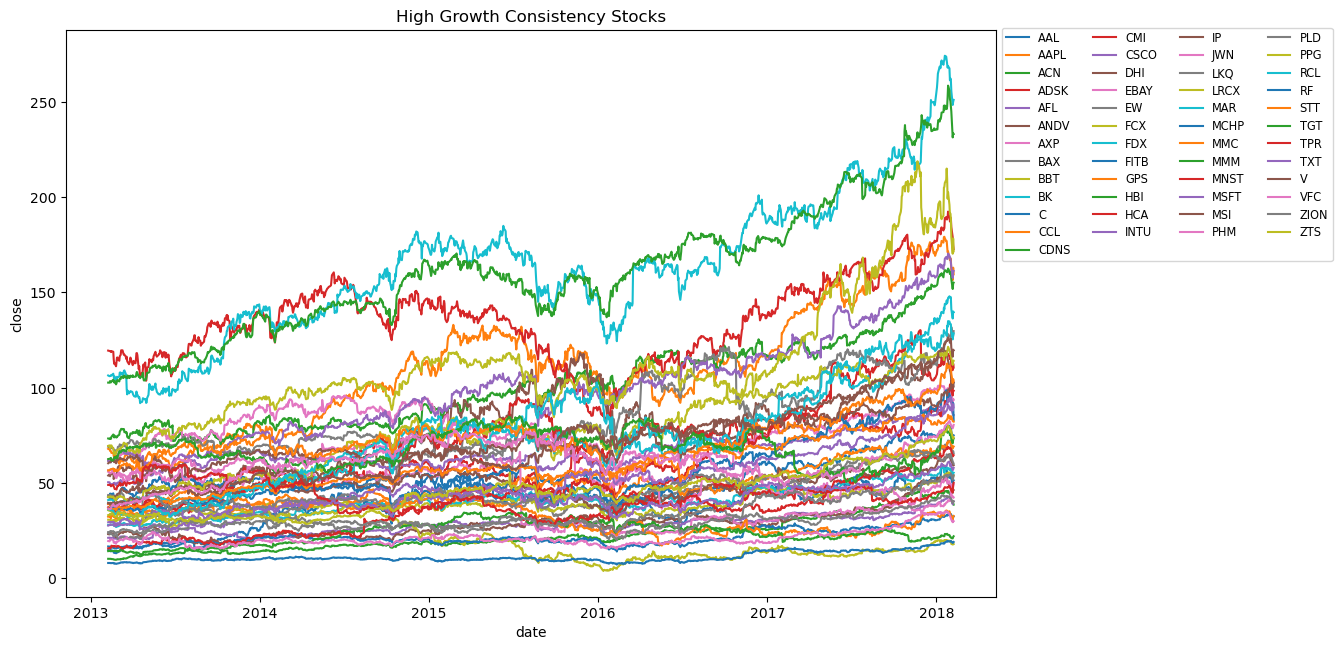

In [366]:
plt.figure(figsize=(12, 7.36))
sns.lineplot(data=original_selection, x='date', y='close', hue='ticks', palette='tab10')
plt.legend(bbox_to_anchor=(1.00, 1.014), loc='upper left', ncol=4, fontsize=8.2)
plt.title('High Growth Consistency Stocks')
plt.show()

In [ ]:
# Correlation to market average returns - Calculate market average correlation
# price_corr = high_growth_stocks.pivot(index='date', columns='ticks', values='close')
# daily_corr = price_corr.pct_change().dropna()
# market_avg = daily_returns.mean(axis=1)
# market_corr = daily_returns.corrwith(market_avg, method='spearman')

# Average correlation with peers - Calculate independent correlation
# corr_matrix = daily_returns.corr(method='spearman')
# np.fill_diagonal(corr_matrix.values, np.nan)
# corr_with_others = corr_matrix.mean(axis=1, skipna=True)

# Positive Predictability
# def positive_predictability(series):
#     returns = series.pct_change().dropna()
#     trend_consistency = (returns.shift(1) * returns > 0).mean()
#     upward_bias = (returns > 0).mean()
#     return trend_consistency * upward_bias

# positive_pred = daily_returns.apply(positive_predictability)

# Create a comprehensive scoring DataFrame
# composite_scoring = pd.DataFrame({
#     'Market_Correlation': market_corr,
#     'Peer_Correlation': corr_with_others,
#     'Positive_Predictability': positive_pred,
# })

In [368]:
# Correlation to market average returns - Calculate market average correlation
pivot = high_growth_stocks.pivot(index='date', columns='ticks', values='close')
daily_returns = pivot.pct_change().dropna()
market_avg = daily_returns.mean(axis=1)
market_corr = daily_returns.corrwith(market_avg, method='spearman')

# Average correlation with peers - Calculate independent correlation
# corr_matrix = daily_returns.corr(method='spearman')
# np.fill_diagonal(corr_matrix.values, np.nan)
# corr_with_others = corr_matrix.mean(axis=1, skipna=True).sort_values(ascending=False)

# Positive Predictability
def positive_predictability(series):
    returns = series.pct_change().dropna()
    # Trend consistency (how often returns follow same direction)
    trend_consistency = (returns.shift(1) * returns > 0).mean()
    # Upward bias (preference for positive returns)
    upward_bias = (returns > 0).mean()
    return trend_consistency * upward_bias  # Both consistent AND upward
positive_pred = daily_returns.apply(positive_predictability)

# Method 1: Weighted combination instead of minimum
forecasting_score_weighted = (0.6 * abs(market_corr) + 0.4 * positive_pred).sort_values(ascending=False)

# Method 2: Harmonic mean (penalizes stocks weak in either metric)
forecasting_score_harmonic = (2 * abs(market_corr) * positive_pred / (abs(market_corr) + positive_pred)).sort_values(ascending=False)

In [359]:
pivot_price = high_growth_stocks.pivot(index='date', columns='ticks', values='close')
pivot_returns = pivot_price.pct_change().dropna()

def calculate_rolling_corr_matrix(data, window):
    """Calculate rolling correlation matrix for all pairs"""
    dates = data.index[window-1:]  # Start from window-1 to have enough data
    rolling_corrs = {}
    
    for date in dates:
        # Get the window of data ending at this date
        window_data = data.loc[:date].tail(window)
        # Calculate correlation matrix for this window
        rolling_corrs[date] = window_data.corr()
    
    return rolling_corrs

# Calculate rolling correlations
price_rolling_corr30 = calculate_rolling_corr_matrix(pivot_price, 30)
price_rolling_corr90 = calculate_rolling_corr_matrix(pivot_price, 90)
returns_rolling_corr30 = calculate_rolling_corr_matrix(pivot_returns, 30)
returns_rolling_corr90 = calculate_rolling_corr_matrix(pivot_returns, 90)

def get_average_correlations(rolling_corr_dict):
    avg_corrs = {}
    
    for date, corr_matrix in rolling_corr_dict.items():
        # For each stock, calculate average correlation with all others
        stock_avg_corrs = {}
        for stock in corr_matrix.columns:
            # Get correlations with all other stocks (exclude self-correlation)
            other_corrs = corr_matrix.loc[stock].drop(stock)
            stock_avg_corrs[stock] = other_corrs.mean()
        
        avg_corrs[date] = stock_avg_corrs
    
    return pd.DataFrame(avg_corrs).T

# Calculate average correlations
avg_price_corr30 = get_average_correlations(price_rolling_corr30)
avg_returns_corr30 = get_average_correlations(returns_rolling_corr30)

# Method 2: Overall average correlation per stock across all time periods
overall_avg_price30 = avg_price_corr30.mean()
overall_avg_returns30 = avg_returns_corr30.mean()

avg_price_corr90 = get_average_correlations(price_rolling_corr90)
avg_returns_corr90 = get_average_correlations(returns_rolling_corr90)

overall_avg_price90 = avg_price_corr90.mean()
overall_avg_returns90 = avg_returns_corr90.mean()

In [360]:
def calculate_rolling_market_corr(data, market_avg, window):
    rolling_corrs = pd.DataFrame(index=data.index, columns=data.columns)
    
    for i in range(window-1, len(data)):
        end_date = data.index[i]
        start_idx = i - window + 1
        
        window_data = data.iloc[start_idx:i+1]
        window_market = market_avg.iloc[start_idx:i+1]
        
        for stock in data.columns:
            rolling_corrs.loc[end_date, stock] = window_data[stock].corr(window_market)
    
    return rolling_corrs

# Calculate rolling market correlations
price_market_rolling_corr30 = calculate_rolling_market_corr(pivot_price, market_avg_prices, 30)
returns_market_rolling_corr30 = calculate_rolling_market_corr(pivot_returns, market_avg_returns, 30)

price_market_rolling_corr90 = calculate_rolling_market_corr(pivot_price, market_avg_prices, 90)
returns_market_rolling_corr90 = calculate_rolling_market_corr(pivot_returns, market_avg_returns, 90)

In [361]:
correlation_analysis = pd.DataFrame({
    'avg_price_corr30':avg_price_corr30.mean(),
    'avg_market_price_corr30':price_market_rolling_corr30.mean(),
    'avg_returns_corr30':avg_returns_corr30.mean(),
    'avg_market_return_corr30':returns_market_rolling_corr30.mean(),
    'avg_price_corr90':avg_price_corr90.mean(),
    'avg_market_price_corr90':price_market_rolling_corr90.mean(),
    'avg_returns_corr90':avg_returns_corr90.mean(),
    'avg_market_returns_corr90':returns_market_rolling_corr90.mean()
})

In [362]:
correlation_analysis.describe()

,avg_price_corr30,avg_returns_corr30,avg_price_corr90,avg_returns_corr90
count,49.000000,49.000000,49.000000,49.000000
mean,0.235779,0.220813,0.381123,0.208302
std,0.065115,0.049550,0.151222,0.051159
min,0.074000,0.099986,-0.071856,0.092213
25%,0.207715,0.184413,0.305843,0.183026
50%,0.238194,0.227769,0.436120,0.219496
75%,0.281635,0.257285,0.497820,0.246875
max,0.354780,0.302301,0.563598,0.295616


In [370]:
print("Stocks with highest predictability correlation:")
print(forecasting_score_weighted.head(10))
print("\nStocks with lowest predictability correlation (most independent):")
print(forecasting_score_weighted.tail(10))

Stocks with highest predictability correlation:
ticks
STT     0.430992
BK      0.426114
FDX     0.411386
ADSK    0.409284
AXP     0.408140
MAR     0.406912
PHM     0.402230
TXT     0.400213
MCHP    0.394209
LKQ     0.393303
dtype: float64

Stocks with lowest predictability correlation (most independent):
ticks
EBAY    0.317678
MMM     0.310366
ZTS     0.305243
MMC     0.295724
EW      0.290489
TGT     0.287722
BAX     0.276238
HCA     0.274620
MNST    0.249684
PLD     0.247508
dtype: float64


In [371]:
print('Average Correlation : {}'.format(forecasting_score_weighted.mean()))

Average Correlation : 0.3506184425955634


In [372]:
high_corr = forecasting_score_weighted[forecasting_score_weighted > forecasting_score_weighted.mean()].index.values
high_correlated_stocks = recent_12m[recent_12m['ticks'].isin(high_corr)]
original_selection = original_selection[original_selection['ticks'].isin(high_corr)]

print('Top {} correlation'.format(len(original_selection['ticks'].unique())))

Top 25 correlation


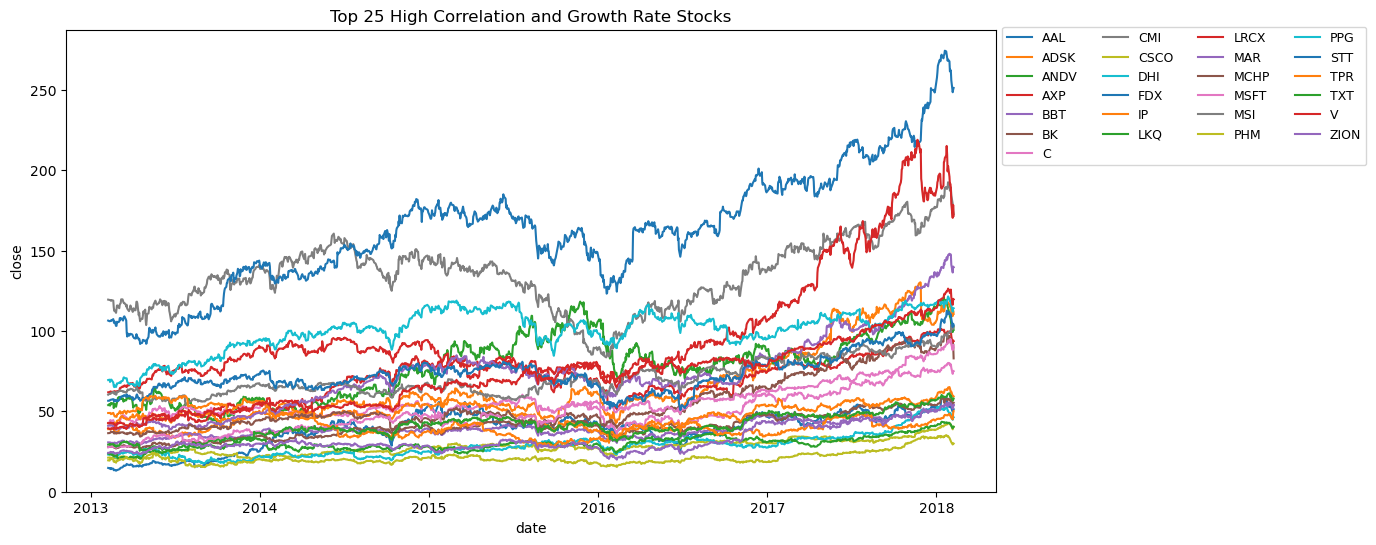

In [373]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=original_selection, x='date', y='close', hue='ticks', palette='tab10')
plt.legend(bbox_to_anchor=(1.00, 1.02), loc='upper left', ncol=4, fontsize=9)
plt.title(f'Top {len(original_selection['ticks'].unique())} High Correlation and Growth Rate Stocks')
plt.show()

In [374]:
original_selection.describe()

,open,high,low,close,volume
count,31475.000000,31475.000000,31475.000000,31475.000000,3.147500e+04
mean,61.631128,62.204833,61.063055,61.652071,6.541621e+06
std,37.043984,37.333246,36.749893,37.050442,1.021698e+07
min,13.140000,13.420000,12.700000,13.020000,2.349790e+05
25%,36.355000,36.750000,35.994950,36.370000,1.740379e+06
50%,50.140000,50.705000,49.650000,50.170000,2.960605e+06
75%,77.447500,78.100000,76.740000,77.435000,6.029170e+06
max,273.950000,274.660000,271.320000,274.320000,2.483542e+08


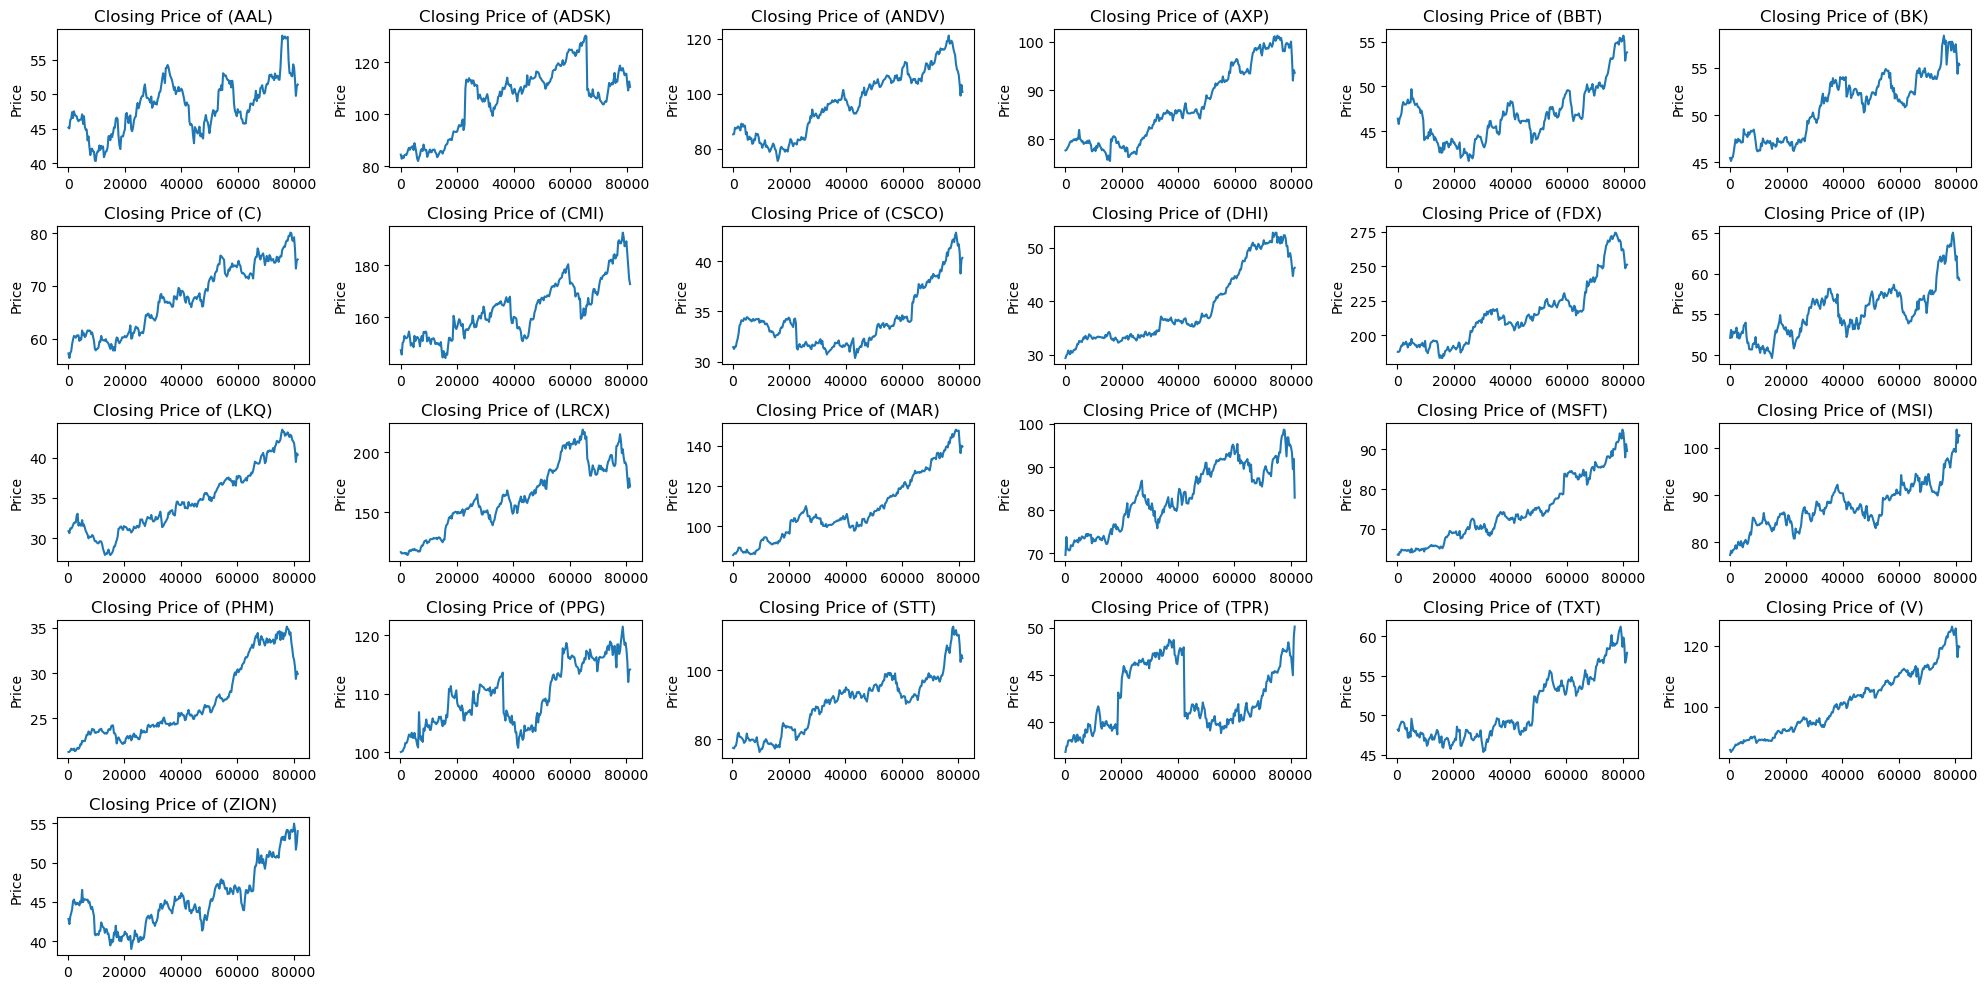

In [376]:
import math

tickers = high_correlated_stocks['ticks'].unique()
n_cols = 6
n_rows = math.ceil(len(tickers) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2 * n_rows))

# Flatten axes for easy iteration even if just one row
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    stock_high_correlated_stocks = high_correlated_stocks[high_correlated_stocks['ticks'] == ticker]
    ax.plot(stock_high_correlated_stocks.index, stock_high_correlated_stocks['close'])
    ax.set_title(f'Closing Price of ({ticker})')
    ax.set_xlabel('')
    ax.set_ylabel('Price')

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

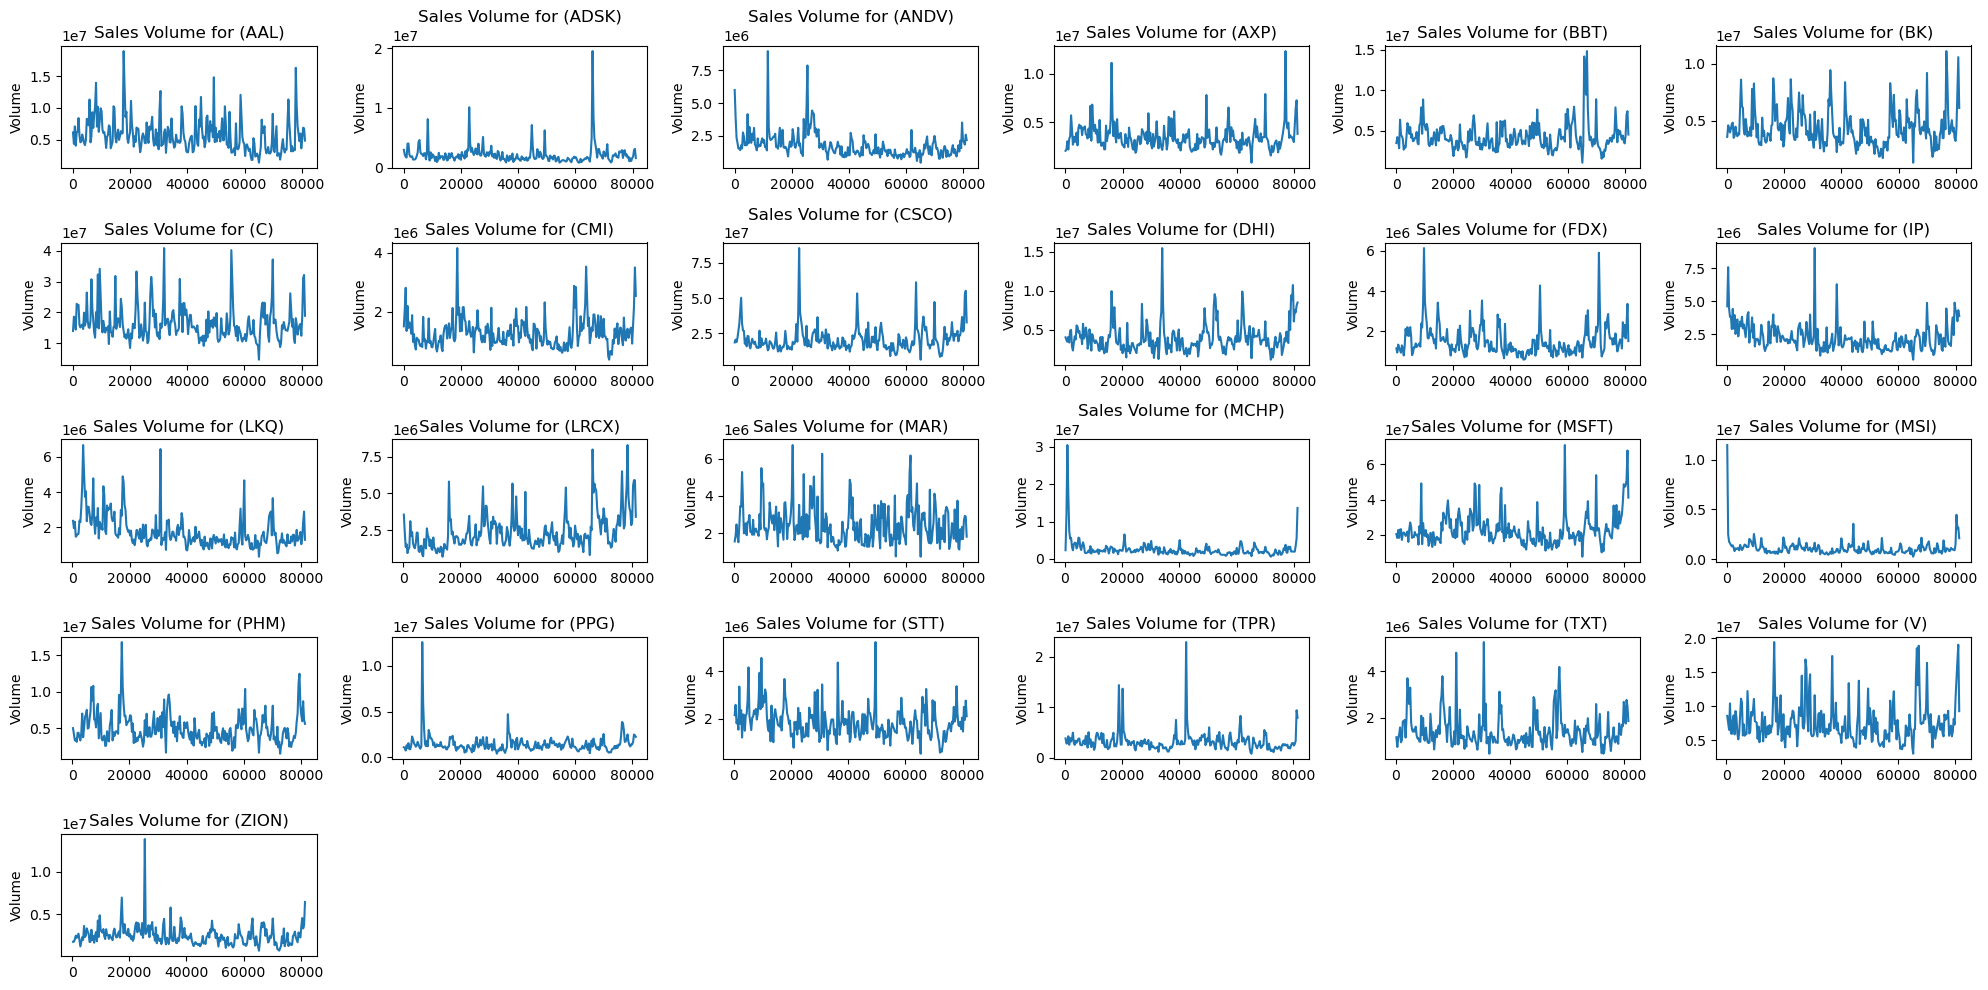

In [377]:
tickers = high_correlated_stocks['ticks'].unique()
n_cols = 6
n_rows = math.ceil(len(tickers) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2 * n_rows))

# Flatten axes for easy iteration even if just one row
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    stock_high_correlated_stocks = high_correlated_stocks[high_correlated_stocks['ticks'] == ticker]
    ax.plot(stock_high_correlated_stocks.index, stock_high_correlated_stocks['volume'])
    ax.set_title(f'Sales Volume for ({ticker})')
    ax.set_xlabel('')
    ax.set_ylabel('Volume')

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

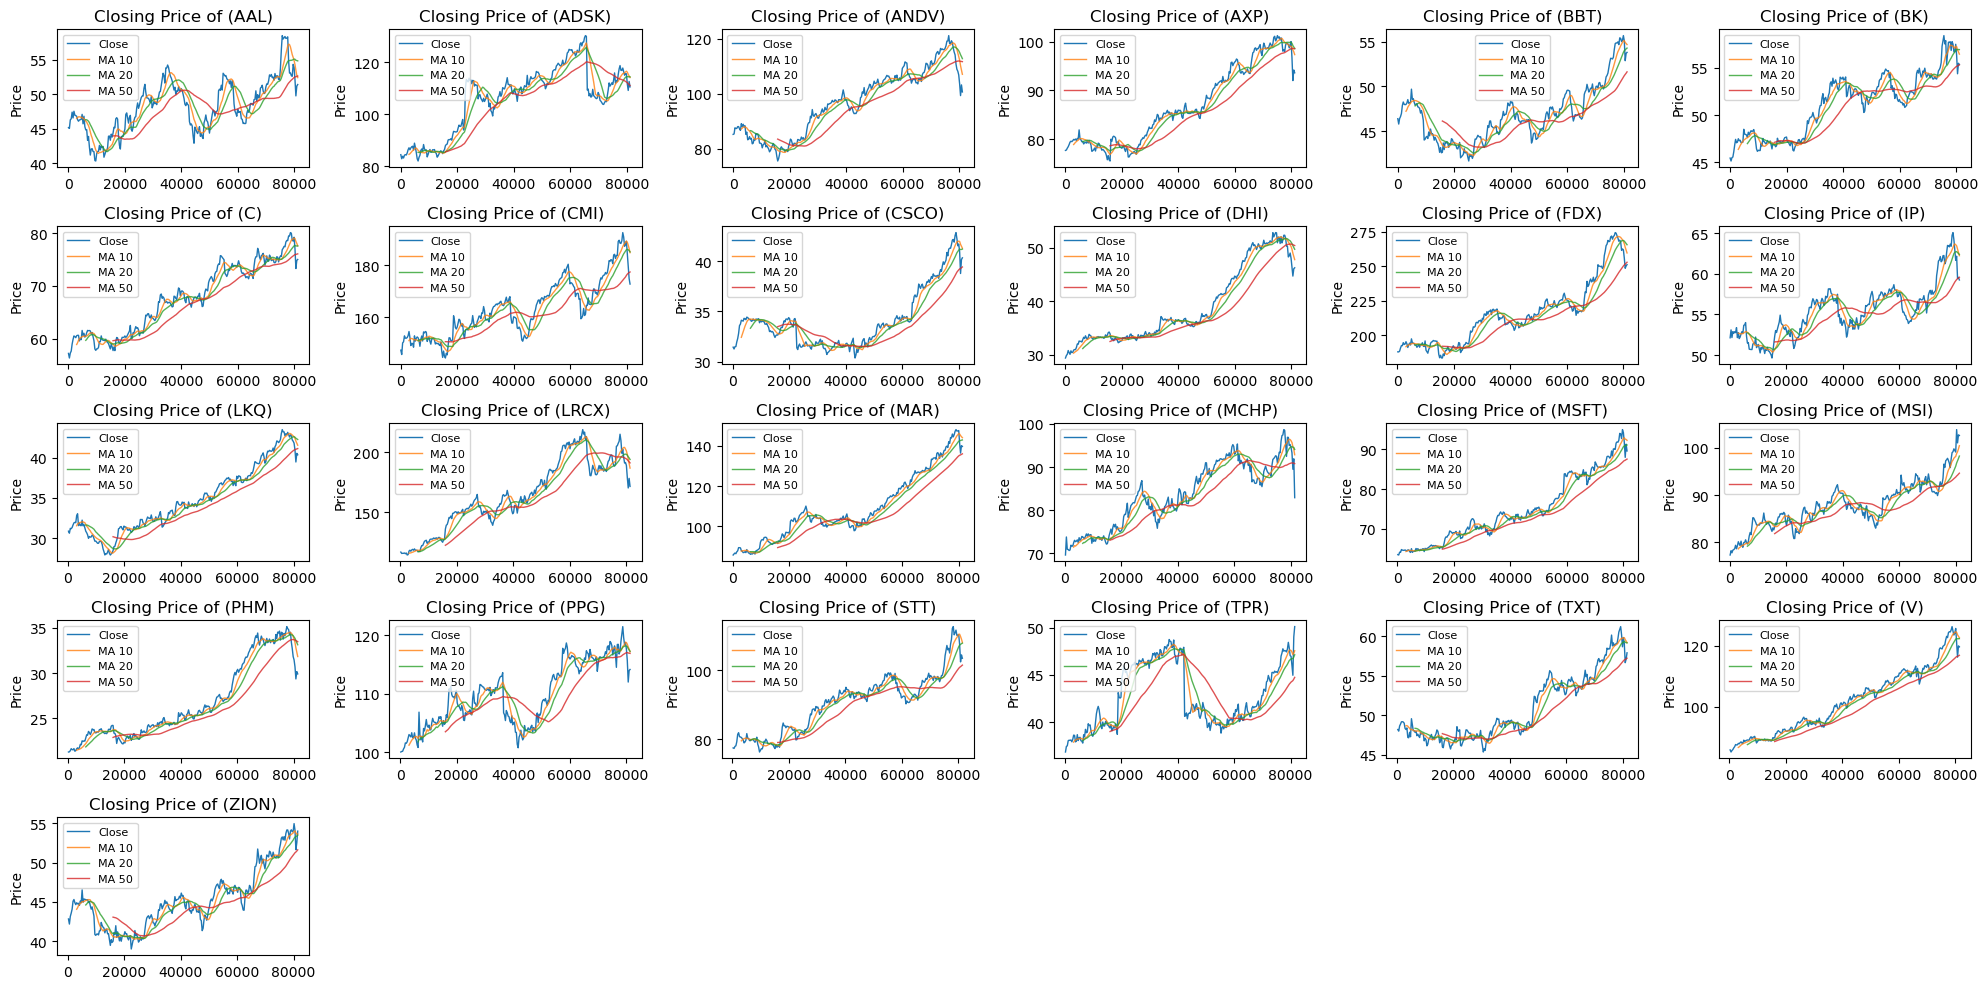

In [378]:
import math
tickers = high_correlated_stocks['ticks'].unique()
n_cols = 6
n_rows = math.ceil(len(tickers) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2 * n_rows))
# Flatten axes for easy iteration even if just one row
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    stock_data = high_correlated_stocks[high_correlated_stocks['ticks'] == ticker]
    
    # Plot close price
    ax.plot(stock_data.index, stock_data['close'], label='Close', linewidth=1)
    
    # Calculate and plot moving averages
    ax.plot(stock_data.index, stock_data['close'].rolling(10).mean(), 
            label='MA 10', alpha=0.8, linewidth=1)
    ax.plot(stock_data.index, stock_data['close'].rolling(20).mean(), 
            label='MA 20', alpha=0.8, linewidth=1)
    ax.plot(stock_data.index, stock_data['close'].rolling(50).mean(), 
            label='MA 50', alpha=0.8, linewidth=1)
    
    ax.set_title(f'Closing Price of ({ticker})')
    ax.set_xlabel('')
    ax.set_ylabel('Price')
    ax.legend(fontsize=8)

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

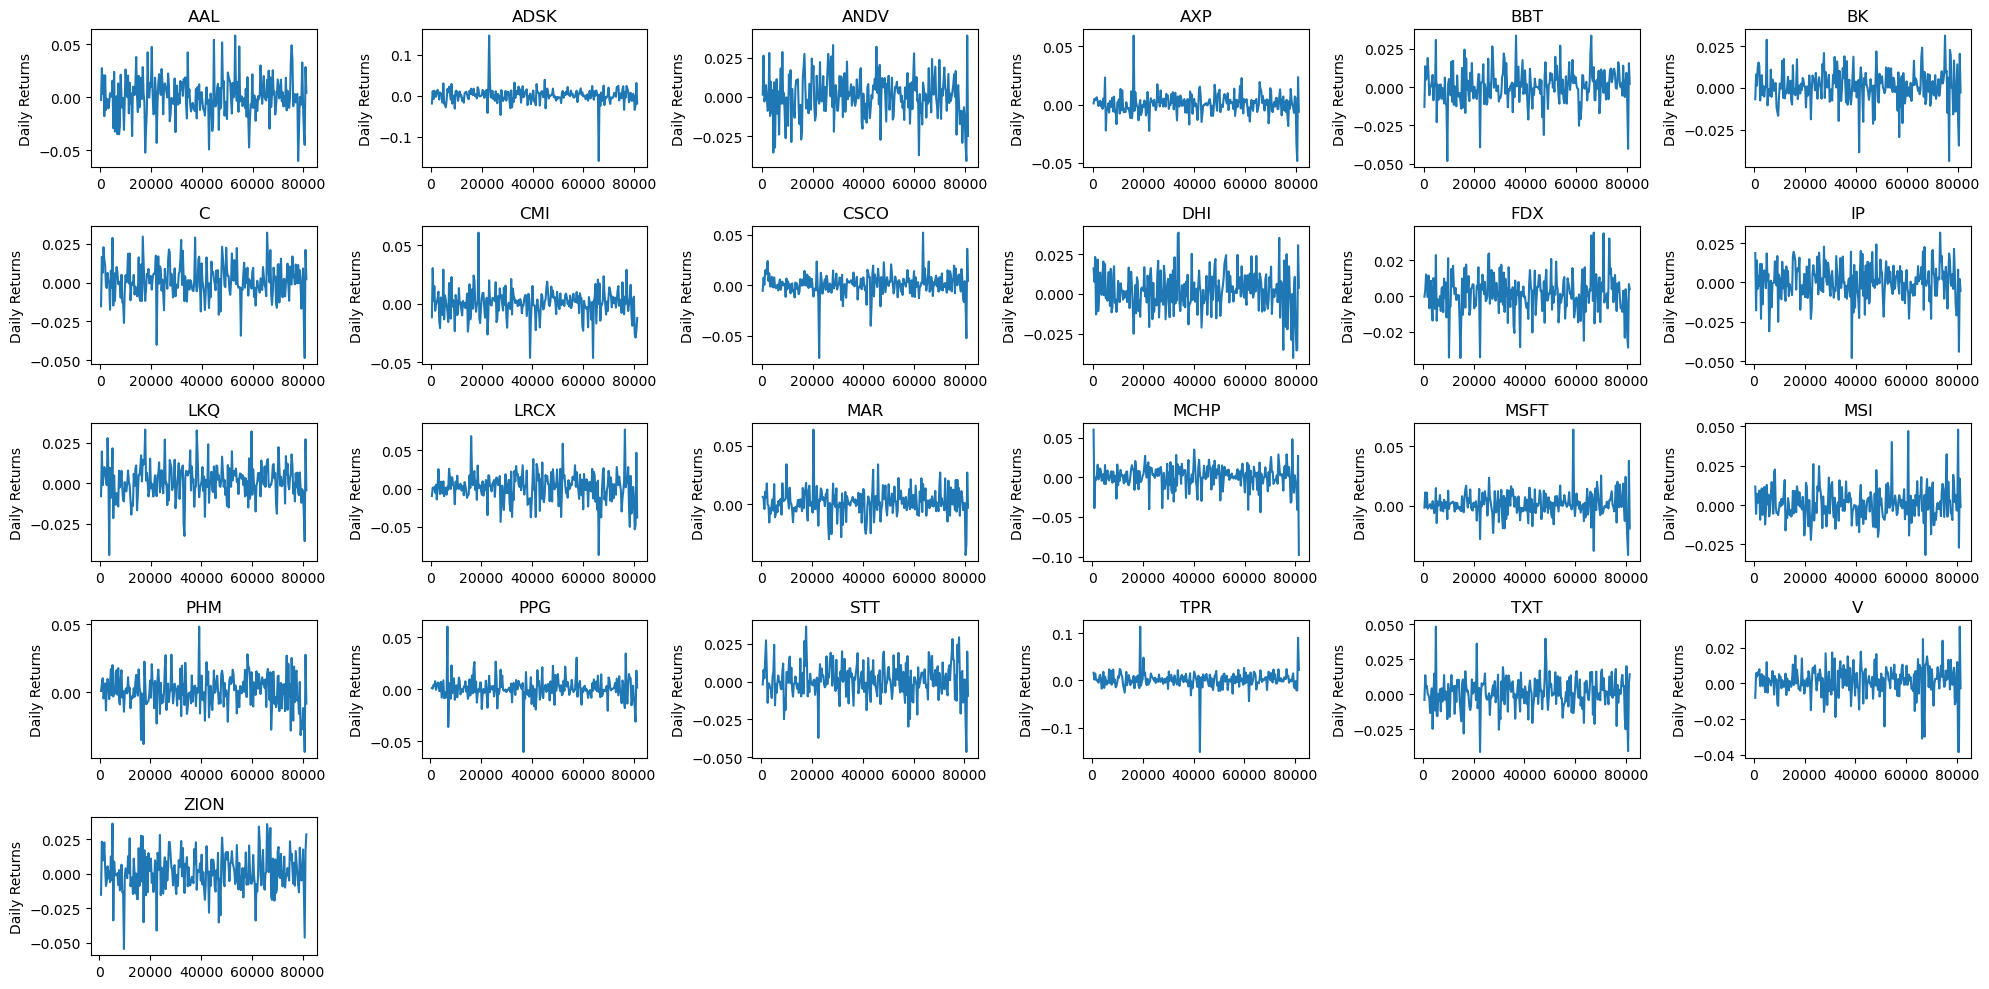

In [ ]:
tickers = high_correlated_stocks['ticks'].unique()

n_cols = 6
n_rows = math.ceil(len(tickers) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2 * n_rows))

# Flatten axes for easy iteration even if just one row
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    stock_high_correlated_stocks = high_correlated_stocks[high_correlated_stocks['ticks'] == ticker]
    ax.plot(stock_high_correlated_stocks.index, stock_high_correlated_stocks.groupby('ticks')['close'].pct_change())
    ax.set_title(f'{ticker}')
    ax.set_xlabel('')
    ax.set_ylabel('Daily Returns')
    # ax.legend()

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

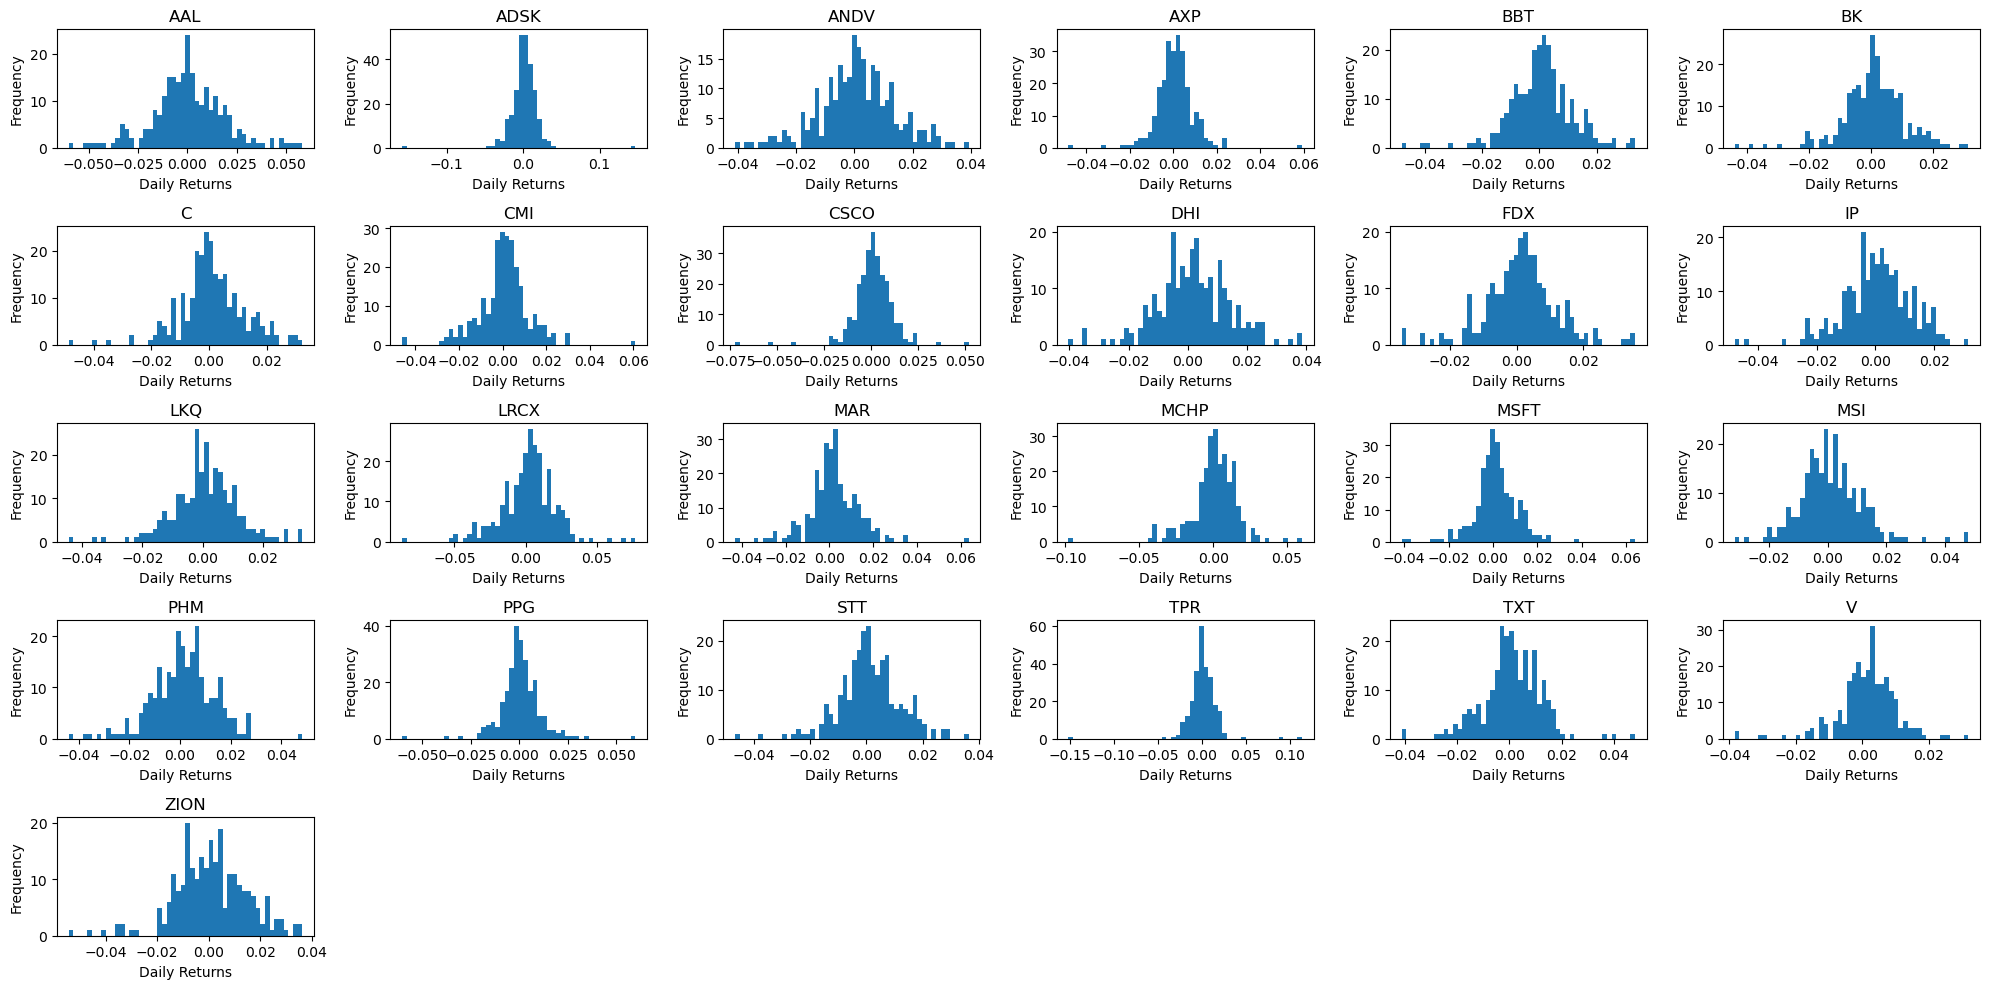

In [381]:
tickers = high_correlated_stocks['ticks'].unique()
n_cols = 6
n_rows = math.ceil(len(tickers) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2 * n_rows))
# Flatten axes for easy iteration even if just one row
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    stock_data = high_correlated_stocks[high_correlated_stocks['ticks'] == ticker]
    ax.hist(stock_data.groupby('ticks')['close'].pct_change().dropna(), bins=50)
    ax.set_title(f'{ticker}')
    ax.set_xlabel('Daily Returns')
    ax.set_ylabel('Frequency')

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation of stock closing price')

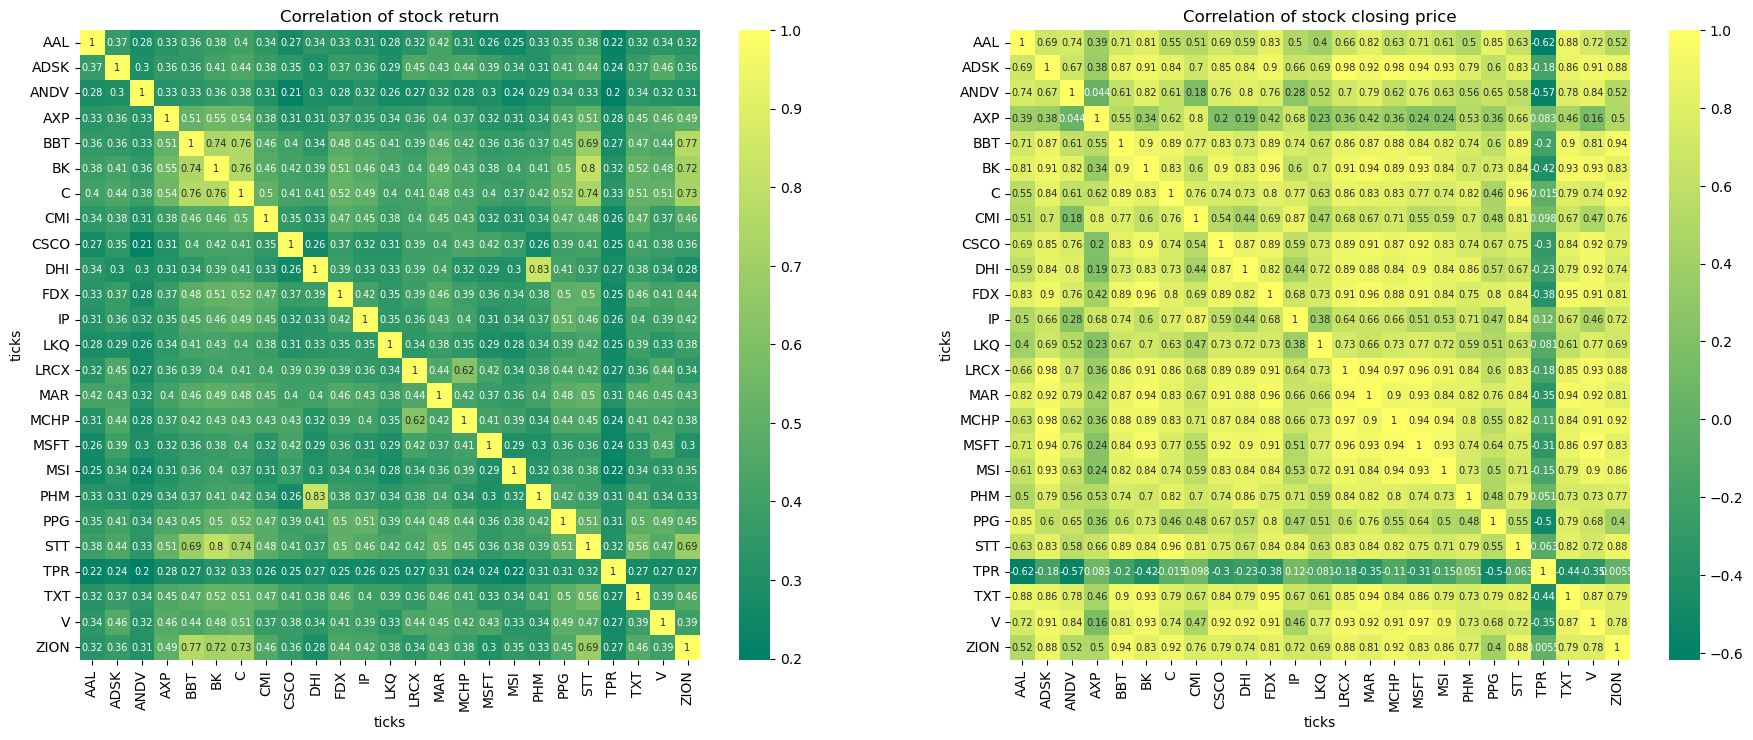

In [394]:
correlated_stocks_corr = original_selection.reset_index().pivot(index='date', columns='ticks', values='close')
correlated_stocks_return = correlated_stocks_corr.pct_change()

plt.figure(figsize=(22, 18))

plt.subplot(2, 2, 1)
sns.heatmap(correlated_stocks_return.corr(), annot=True, cmap='summer', annot_kws={'size': 7})
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(correlated_stocks_corr.corr(), annot=True, cmap='summer', annot_kws={'size': 7})
plt.title('Correlation of stock closing price')

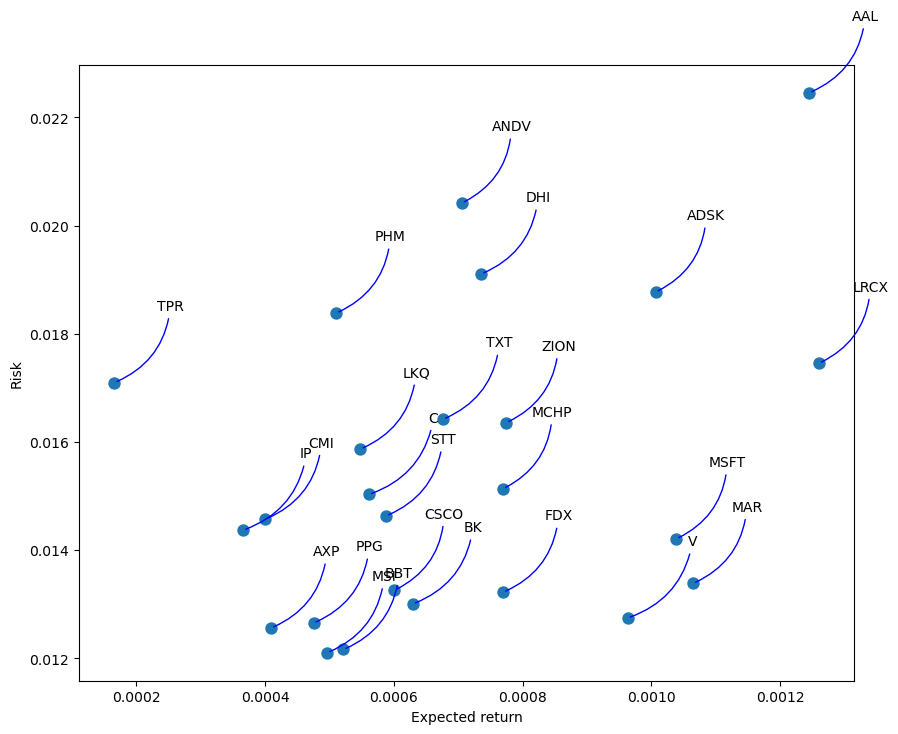

In [395]:
rets = correlated_stocks_return.dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom', 
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))

In [510]:
stocks_to_select = ['MSFT', 'MAR', 'V', 'LRCX', 'ADSK']

In [511]:
high_expected_return = original_selection[original_selection['ticks'].isin(stocks_to_select)]
len(high_expected_return['ticks'].unique())

5

In [512]:
high_expected_return.ticks.unique()

array(['ADSK', 'LRCX', 'MAR', 'MSFT', 'V'], dtype=object)

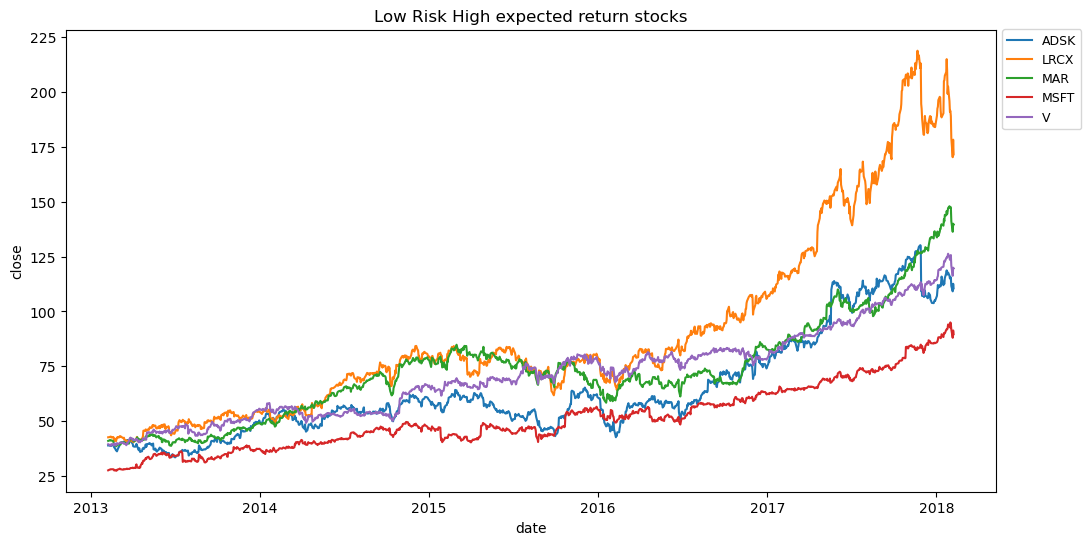

In [513]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=high_expected_return, x='date', y='close', hue='ticks')
plt.legend(bbox_to_anchor=(1.00, 1.015), loc='upper left', fontsize=9)
plt.title('Low Risk High expected return stocks')
plt.show()

In [514]:
from sklearn.preprocessing import MinMaxScaler

pivot = high_expected_return.pivot(columns='ticks', values='close').sort_values('date')
train = pivot[pivot.index <= (pivot.index.max() - pd.DateOffset(months=3))]
val = pivot[pivot.index >= (pivot.index.max() - pd.DateOffset(months=3))]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)

In [515]:
def create_simple_sequences(data, time_steps):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i])
    return np.array(X), np.array(y)

time_steps = 30
X_train, y_train = create_simple_sequences(train_scaled, time_steps)
X_val, y_val = create_simple_sequences(val_scaled, time_steps)

print("Train data shape:", train.shape)
print("Train data contains zeros:", (train == 0).sum().sum())
print("Train scaled min/max:", train_scaled.min(), train_scaled.max())
print("X_train has NaN:", np.isnan(X_train).any())
print("y_train has NaN:", np.isnan(y_train).any())

Train data shape: (1197, 5)
Train data contains zeros: 0
Train scaled min/max: 0.0 1.0000000000000002
X_train has NaN: False
y_train has NaN: False


In [516]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(time_steps, 5)),
    Dense(32, activation='relu'), 
    Dense(5)
])

model.compile(optimizer='adam', loss='mean_squared_error')
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/50


/home/n/.conda/envs/statsenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0361 - val_loss: 0.0481
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036 - val_loss: 0.0191
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 - val_loss: 0.0274
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 - val_loss: 0.0227
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0201
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010 - val_loss: 0.0203
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.0002e-04 - val_loss: 0.0185
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.4797e-04 - val_loss: 0.0172
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.8405e-04 - val_loss: 0.0143
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.6876e-04 - val_loss: 0.0135
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3032e-04 - val_loss: 0.0111
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.9072

In [517]:
# Now make predictions
y_pred = model.predict(X_val)

# Inverse transform to get actual stock prices
y_val_actual = scaler.inverse_transform(y_val)
y_pred_actual = scaler.inverse_transform(y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


RMSE: 9.35
MAE: 7.05


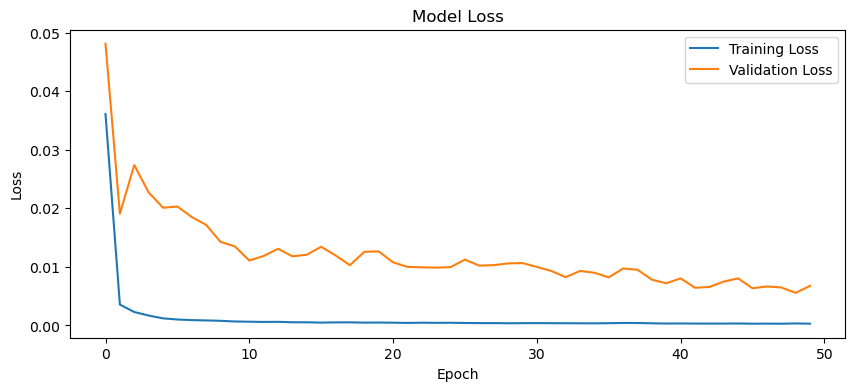

In [518]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_val_actual, y_pred_actual)
mae = mean_absolute_error(y_val_actual, y_pred_actual)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

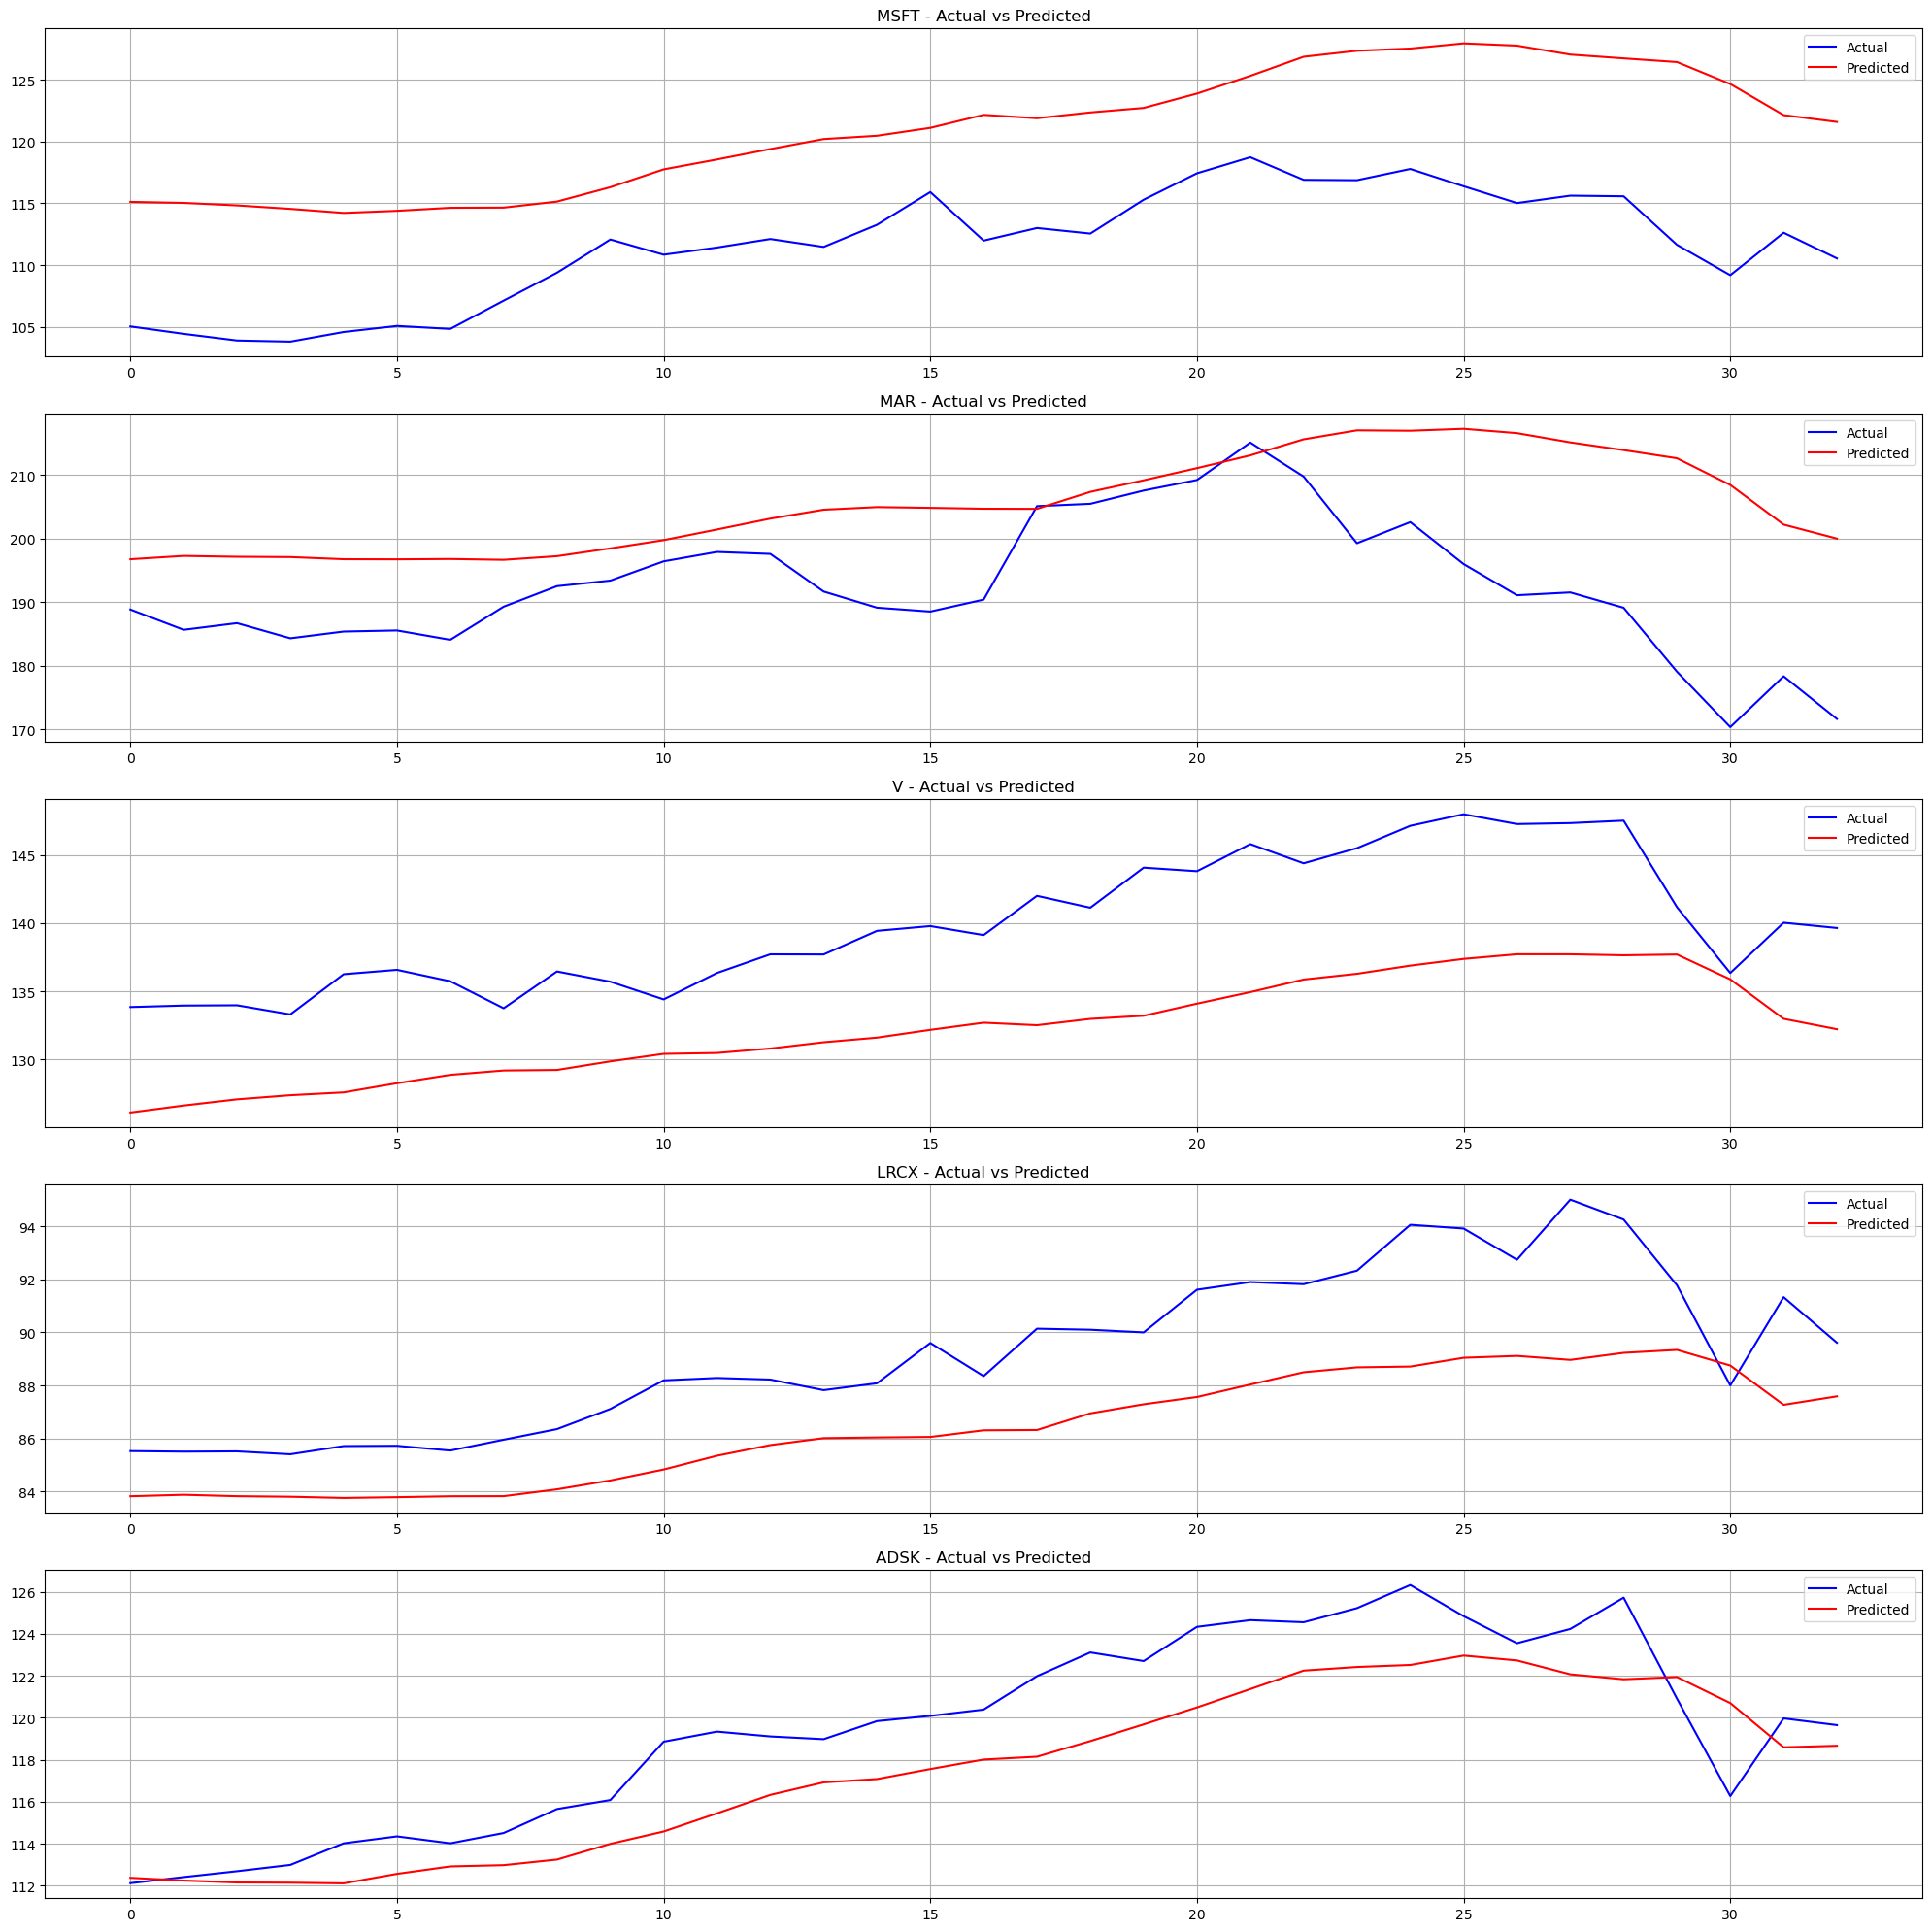

In [ ]:
import matplotlib.pyplot as plt

# Plot for each stock
stock_names = ['MSFT', 'MAR', 'V', 'LRCX', 'ADSK']

fig, axes = plt.subplots(len(stock_names), 1, figsize=(12, 10))

for i, stock in enumerate(stock_names):
    axes[i].plot(y_val_actual[:, i], label='Actual', color='blue')
    axes[i].plot(y_pred_actual[:, i], label='Predicted', color='red')
    axes[i].set_title(f'{stock} - Actual vs Predicted')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [523]:
def evaluate_individual_models(stock_models, stock_scalers, selected_stocks, val_data):
    results = {}
    
    for stock in selected_stocks:
        model = stock_models[stock]
        scaler = stock_scalers[stock]
        
        # Prepare validation data for this stock
        stock_val_data = val_data[stock].values.reshape(-1, 1)
        scaled_val_data = scaler.transform(stock_val_data)
        
        # Create sequences for validation
        X_val, y_val = [], []
        time_steps = 30
        for i in range(time_steps, len(scaled_val_data)):
            X_val.append(scaled_val_data[i-time_steps:i])
            y_val.append(scaled_val_data[i])
        
        X_val, y_val = np.array(X_val), np.array(y_val)
        
        # Make predictions
        y_pred = model.predict(X_val)
        
        # Inverse transform
        y_val_actual = scaler.inverse_transform(y_val)
        y_pred_actual = scaler.inverse_transform(y_pred)
        
        # Calculate metrics
        mse = mean_squared_error(y_val_actual, y_pred_actual)
        mae = mean_absolute_error(y_val_actual, y_pred_actual)
        rmse = np.sqrt(mse)
        
        results[stock] = {
            'rmse': rmse,
            'mae': mae,
            'actual': y_val_actual.flatten(),
            'predicted': y_pred_actual.flatten()
        }
        
        print(f"{stock} - RMSE: {rmse:.2f}, MAE: {mae:.2f}")
    
    return results

# Evaluate all models
evaluation_results = evaluate_individual_models(stock_models, stock_scalers, 
                                              selected_stocks, val)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
ADSK - RMSE: 1.98, MAE: 1.67
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
LRCX - RMSE: 5.11, MAE: 3.60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
MSFT - RMSE: 1.52, MAE: 1.16
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 
MAR - RMSE: 2.21, MAE: 1.48
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
V - RMSE: 1.72, MAE: 1.29


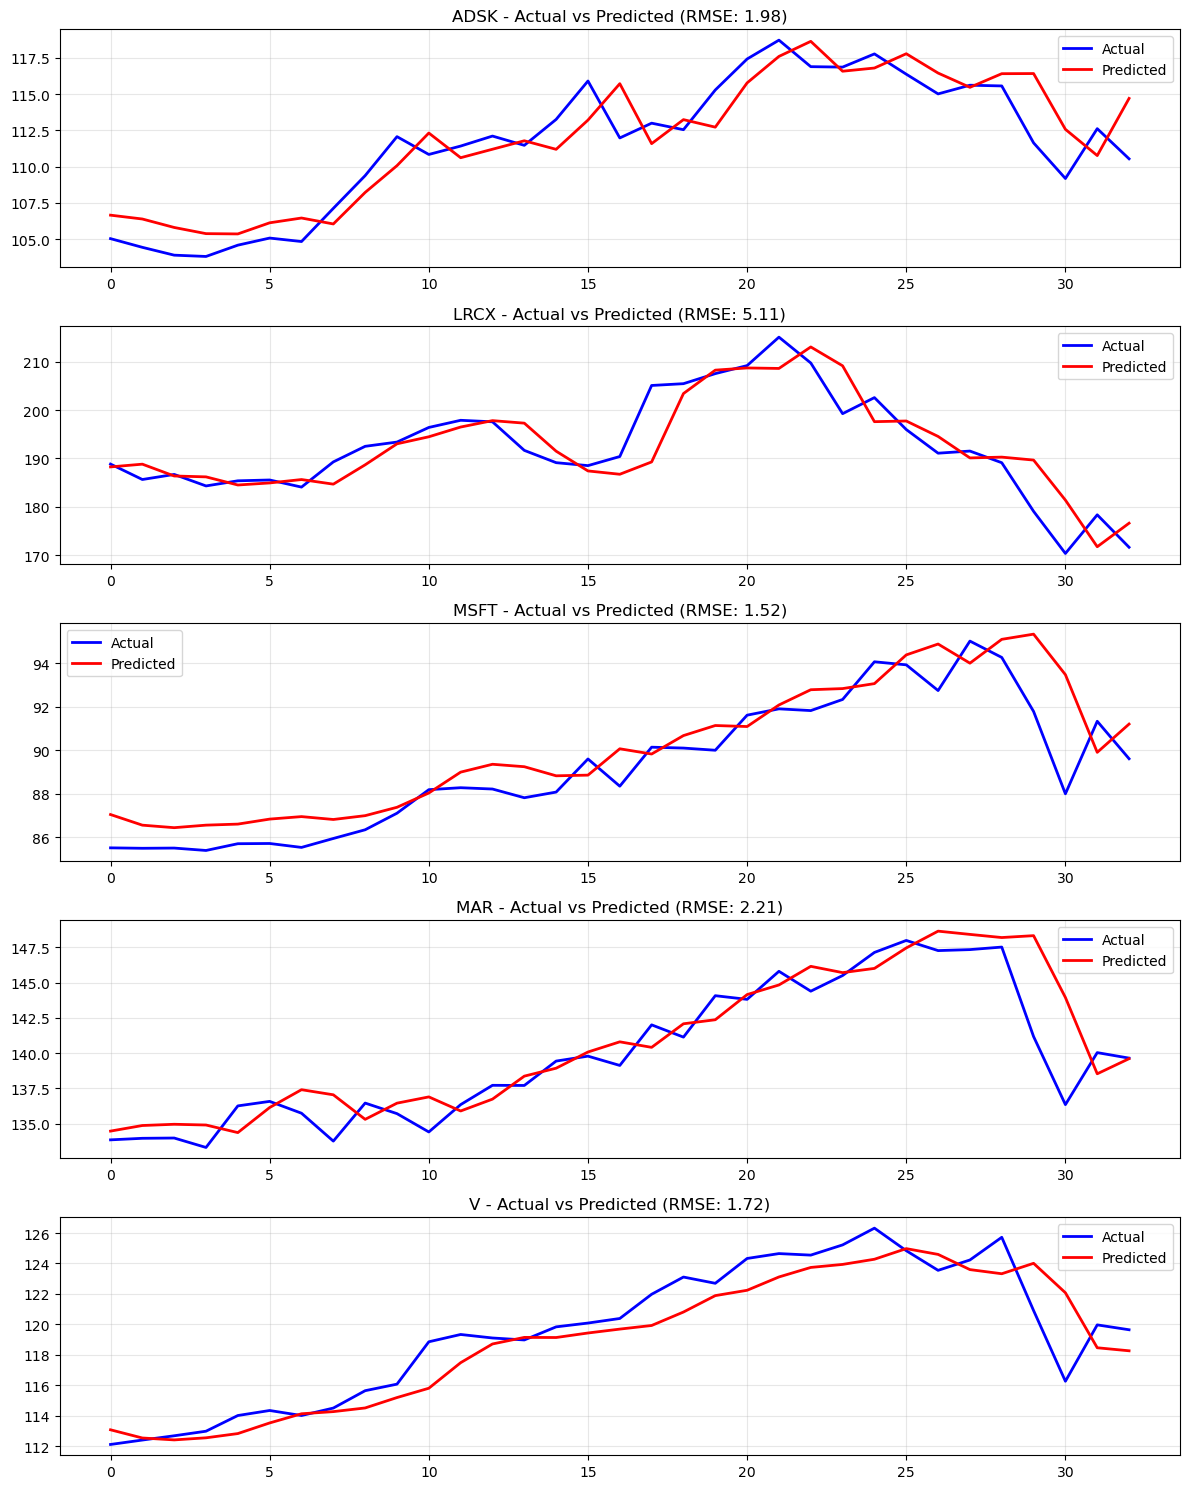

In [524]:
def plot_individual_results(evaluation_results, selected_stocks):
    fig, axes = plt.subplots(len(selected_stocks), 1, figsize=(12, 15))
    
    for i, stock in enumerate(selected_stocks):
        actual = evaluation_results[stock]['actual']
        predicted = evaluation_results[stock]['predicted']
        rmse = evaluation_results[stock]['rmse']
        
        axes[i].plot(actual, label='Actual', color='blue', linewidth=2)
        axes[i].plot(predicted, label='Predicted', color='red', linewidth=2)
        axes[i].set_title(f'{stock} - Actual vs Predicted (RMSE: {rmse:.2f})')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_individual_results(evaluation_results, selected_stocks)

In [525]:
def predict_future_prices(stock_models, stock_scalers, train_data, days_ahead=90):
    predictions = {}
    
    for stock in selected_stocks:
        model = stock_models[stock]
        scaler = stock_scalers[stock]
        
        # Get last 30 days from training data
        last_30_days = train_data[stock].tail(30).values.reshape(-1, 1)
        scaled_sequence = scaler.transform(last_30_days)
        
        future_predictions = []
        current_sequence = scaled_sequence.copy()
        
        # Predict day by day for 90 days
        for _ in range(days_ahead):
            # Predict next day
            next_day_scaled = model.predict(current_sequence.reshape(1, 30, 1))
            future_predictions.append(next_day_scaled[0, 0])
            
            # Update sequence (remove first, add prediction)
            current_sequence = np.append(current_sequence[1:], next_day_scaled.reshape(1, 1), axis=0)
        
        # Inverse transform predictions
        future_predictions = np.array(future_predictions).reshape(-1, 1)
        future_prices = scaler.inverse_transform(future_predictions).flatten()
        
        predictions[stock] = future_prices
        print(f"{stock} - 3-month prediction range: ${future_prices.min():.2f} to ${future_prices.max():.2f}")
    
    return predictions

# Generate 3-month predictions
future_predictions = predict_future_prices(stock_models, stock_scalers, train)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━

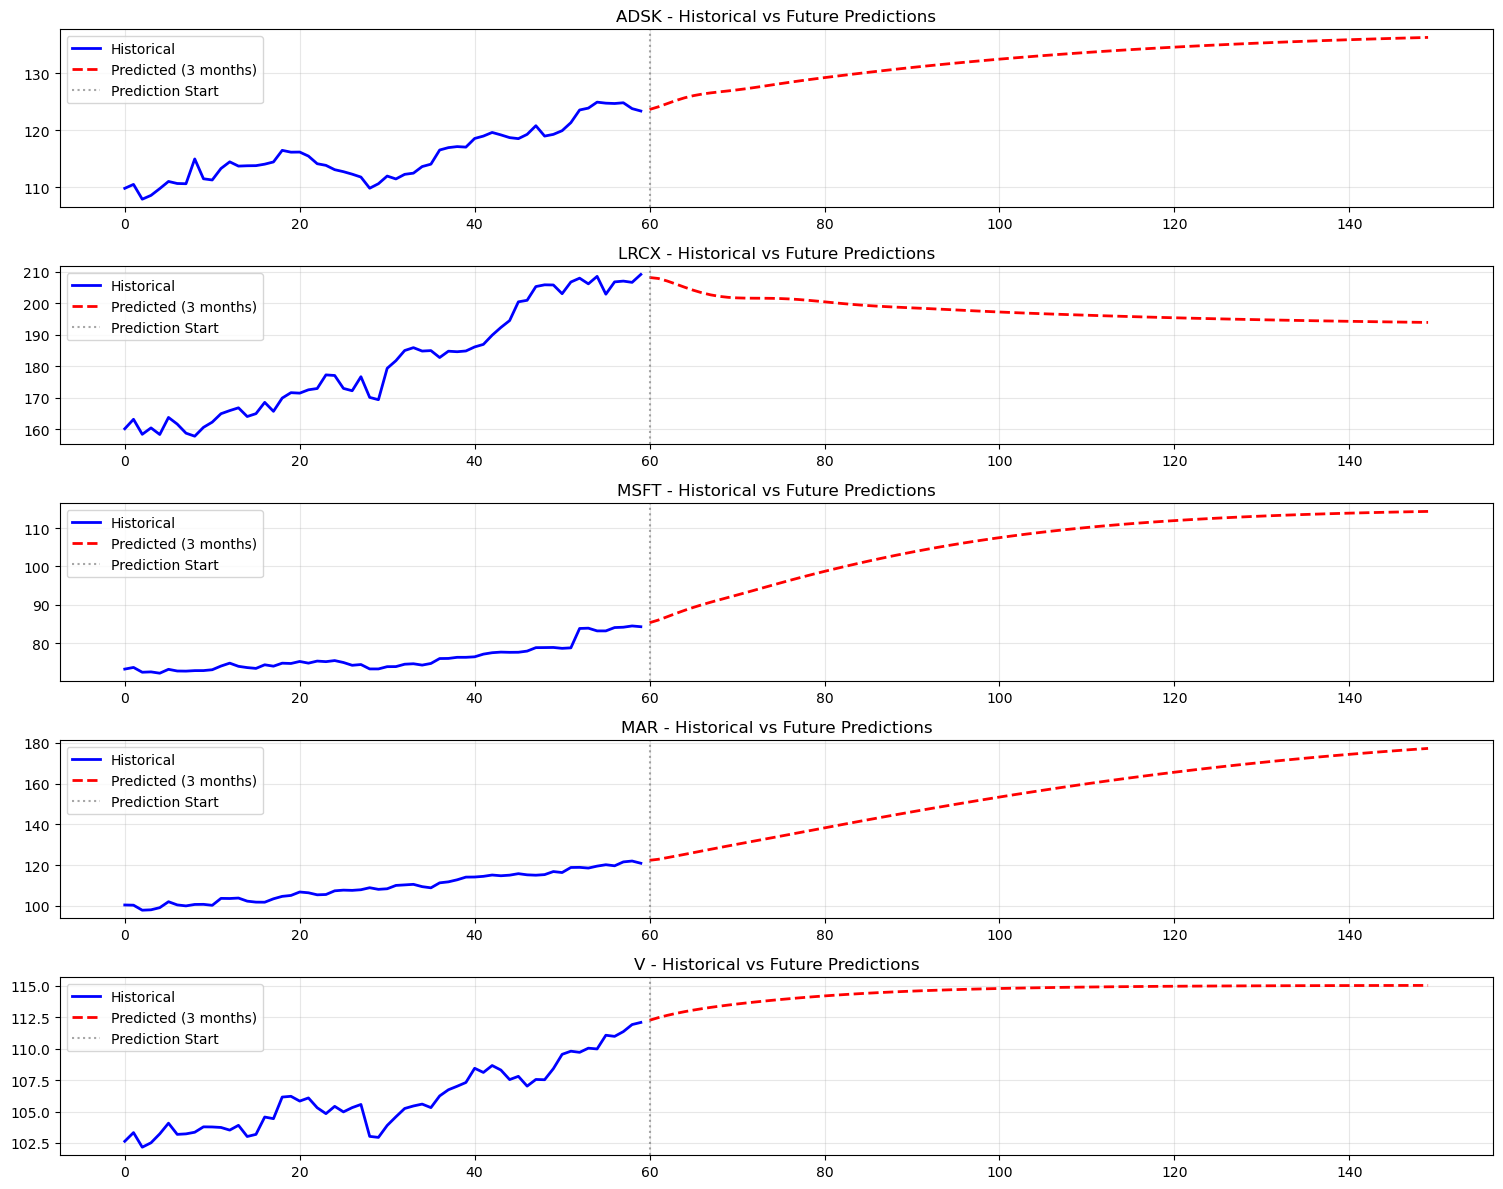

In [ ]:
def plot_future_predictions(train_data, future_predictions, selected_stocks):
    fig, axes = plt.subplots(len(selected_stocks), 1, figsize=(15, 12))
    
    for i, stock in enumerate(selected_stocks):
        # Historical data
        historical = train_data[stock].tail(60)  # Last 60 days
        future = future_predictions[stock]
        
        # Create date ranges
        hist_dates = range(len(historical))
        future_dates = range(len(historical), len(historical) + len(future))
        
        axes[i].plot(hist_dates, historical.values, label='Historical', color='blue', linewidth=2)
        axes[i].plot(future_dates, future, label='Predicted (3 months)', color='red', linewidth=2, linestyle='--')
        axes[i].axvline(x=len(historical), color='gray', linestyle=':', alpha=0.7, label='Prediction Start')
        axes[i].set_title(f'{stock} - Historical vs Future Predictions')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_future_predictions(train, future_predictions, selected_stocks)

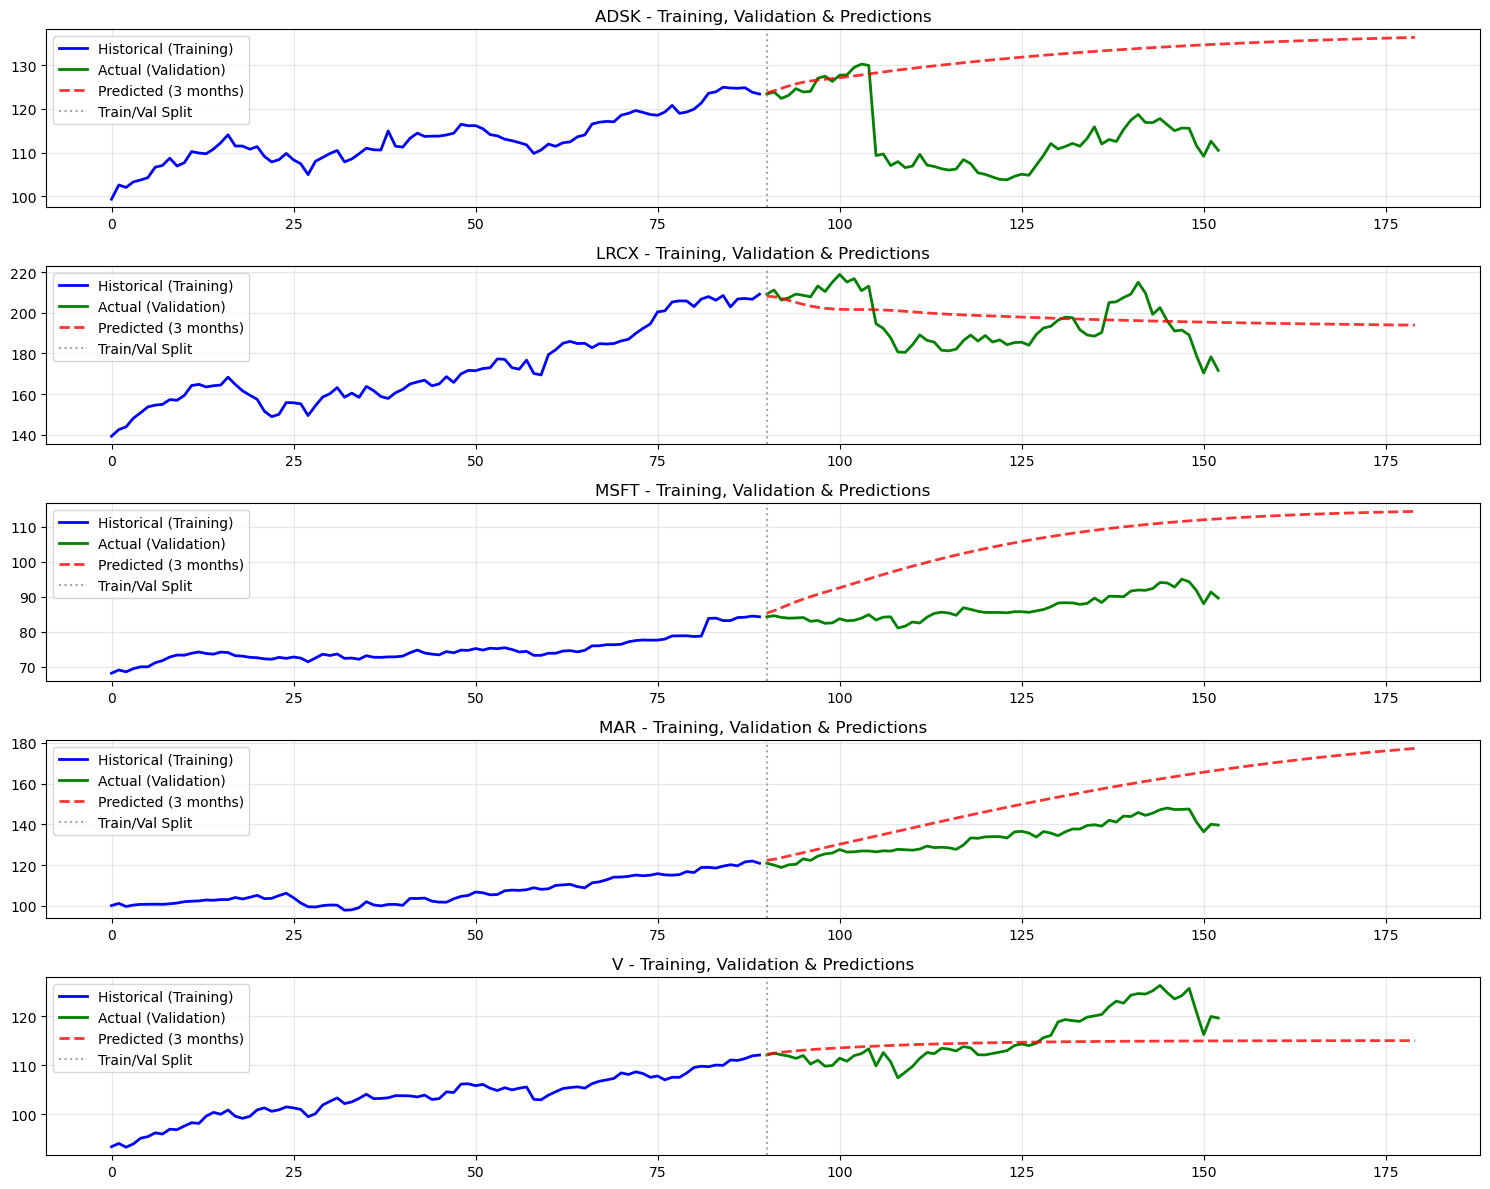

In [528]:
def plot_future_predictions(train_data, val_data, future_predictions, selected_stocks):
    fig, axes = plt.subplots(len(selected_stocks), 1, figsize=(15, 12))
    
    for i, stock in enumerate(selected_stocks):
        # Historical training data (last 60 days)
        historical = train_data[stock].tail(90)
        # Validation data (actual 3 months)
        validation = val_data[stock]
        # Future predictions (3 months)
        future = future_predictions[stock]
        
        # Create date ranges
        hist_dates = range(len(historical))
        val_dates = range(len(historical), len(historical) + len(validation))
        future_dates = range(len(historical), len(historical) + len(future))
        
        # Plot all three datasets
        axes[i].plot(hist_dates, historical.values, label='Historical (Training)', 
                    color='blue', linewidth=2)
        axes[i].plot(val_dates, validation.values, label='Actual (Validation)', 
                    color='green', linewidth=2)
        axes[i].plot(future_dates, future, label='Predicted (3 months)', 
                    color='red', linewidth=2, linestyle='--', alpha=0.8)
        
        axes[i].axvline(x=len(historical), color='gray', linestyle=':', 
                       alpha=0.7, label='Train/Val Split')
        axes[i].set_title(f'{stock} - Training, Validation & Predictions')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Call with all three datasets
plot_future_predictions(train, val, future_predictions, selected_stocks)